#### Imports

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
import time
import os
import json
import math

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from openai import OpenAI
client = OpenAI()

In [2]:
df = pd.read_csv("complaints.csv")
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-12-27,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,NaN,Experian Information Solutions Inc.,IN,464XX,NaN,NaN,Web,2025-12-27,In progress,Yes,NaN,18309451
2,2025-11-25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30311,NaN,NaN,Web,2025-11-25,In progress,Yes,NaN,17487731


In [3]:
df.shape

(13019300, 18)

#### Slice data using a temporal range and consumer narrative only rows

In [4]:
# Slice data by date
df.columns = [c.strip() for c in df.columns]

df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

# keep only 2018–2025
df = df[
    (df["Date received"].dt.year >= 2018) &
    (df["Date received"].dt.year <= 2025)
].copy()


print("After time filter:", df.shape)

After time filter: (11881143, 18)


In [5]:
df = df[
    (df["Consumer complaint narrative"].notna()) &
    (df["Consumer consent provided?"] == "Consent provided")
].copy()

print("After narrative filter:", df.shape)

After narrative filter: (3406401, 18)


#### Complaints Trend from 2018 to 2025 (where we have a consumer narrative)

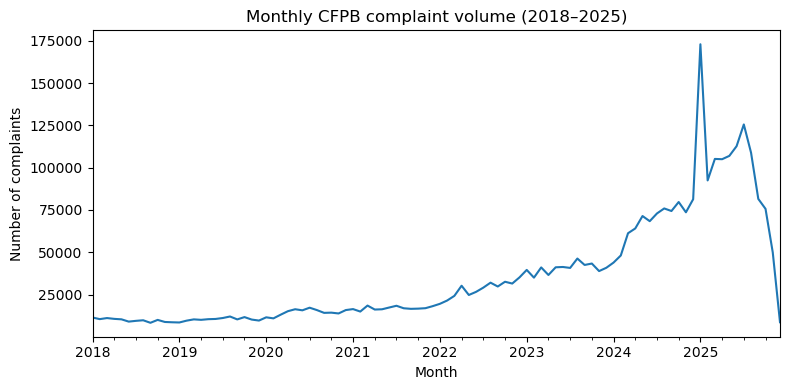

In [6]:
df_trend = df.dropna(subset=["Date received"]).copy()
df_trend["month"] = df_trend["Date received"].dt.to_period("M").dt.to_timestamp()

monthly_counts = df_trend.groupby("month").size()

plt.figure(figsize=(8,4))
monthly_counts.plot()
plt.title("Monthly CFPB complaint volume (2018–2025)")
plt.xlabel("Month")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()

#### Missing data checks 

In [8]:
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_tbl = missing_pct.reset_index()
missing_tbl.columns = ["Column", "Missing (%)"]
missing_tbl


,Column,Missing (%)
0,Consumer disputed?,100.00
1,Tags,91.08
2,Company public response,45.62
3,Sub-issue,6.58
4,State,0.35
5,Date received,0.00
6,Consumer consent provided?,0.00
7,Timely response?,0.00
8,Company response to consumer,0.00
9,Date sent to company,0.00


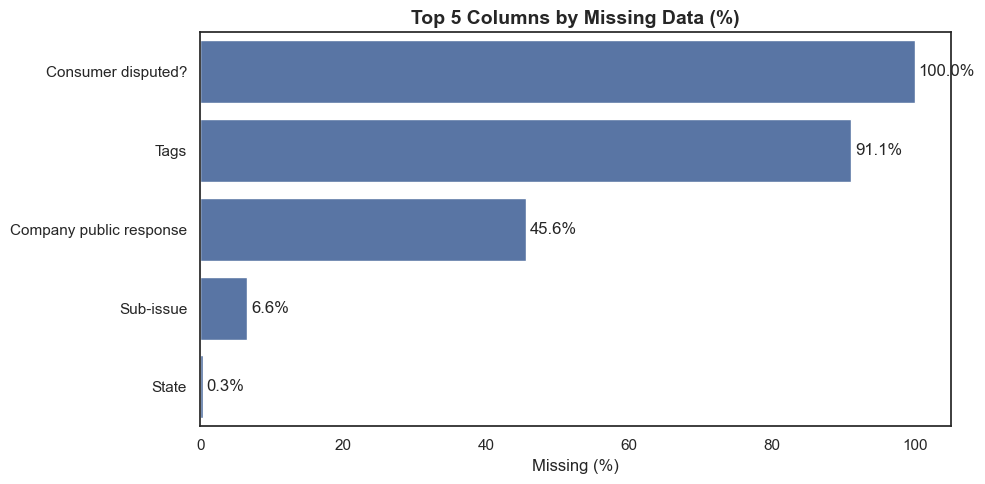

In [37]:
# Prepare data
top_missing = (
    missing_tbl
    .set_index("Column")["Missing (%)"]
    .head(5)
    .reset_index()
)

# Remove grid style
sns.set_style("white")   # <-- No grid

plt.figure(figsize=(10, 5))

palette = sns.color_palette("viridis", len(top_missing))

ax = sns.barplot(
    data=top_missing,
    x="Missing (%)",
    y="Column"
    # palette=palette
)

# Remove any remaining grid explicitly
ax.grid(False)

plt.title("Top 5 Columns by Missing Data (%)", fontsize=14, weight="bold")
plt.xlabel("Missing (%)")
plt.ylabel("")

# Add % labels
for i, value in enumerate(top_missing["Missing (%)"]):
    ax.text(value + 0.5, i, f"{value:.1f}%", va="center")

plt.xlim(0, top_missing["Missing (%)"].max() + 5)

plt.tight_layout()
plt.show()


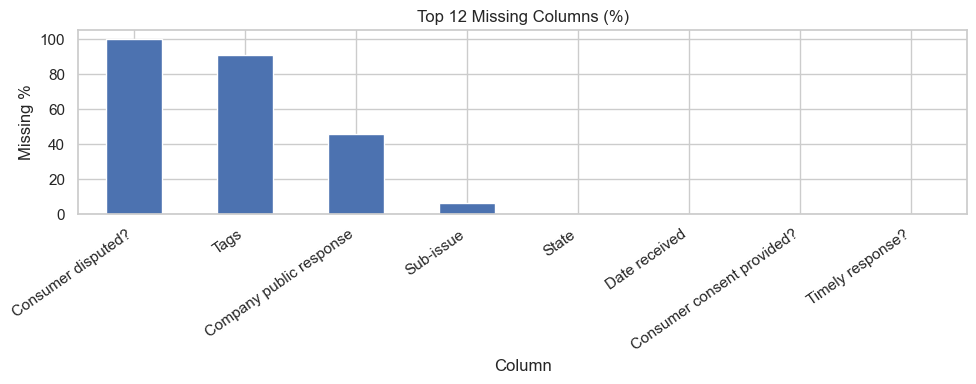

In [24]:
plt.figure(figsize=(10,4))
missing_tbl.set_index("Column")["Missing (%)"].head(8).plot(kind="bar")
plt.title("Top 12 Missing Columns (%)")
plt.ylabel("Missing %")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [9]:
dup_count = df.duplicated(subset=["Complaint ID"]).sum() # check based on - 
dup_pct = dup_count / len(df) * 100

dup_count, round(dup_pct, 4)

(0, 0.0)

In [10]:
df["Date sent to company"] = pd.to_datetime(df["Date sent to company"], errors="coerce")
invalid = (df["Date sent to company"] < df["Date received"]).sum()
print("Invalid date rows (sent < received):", invalid)

Invalid date rows (sent < received): 0


#### Cardinality check for each variable

In [11]:
categorical_cols = ["Product", "Sub-product", "Issue", "Sub-issue",
                    "Company", "State", "Submitted via"]
unique_vals = {col: df[col].nunique(dropna=True) for col in categorical_cols}
pd.Series(unique_vals).sort_values(ascending=False)

Company          6071
Sub-issue         212
Issue              93
State              63
Sub-product        58
Product            14
Submitted via       1
dtype: int64

In [12]:
df["Submitted via"].value_counts()

Submitted via
Web    3406401
Name: count, dtype: int64

In [33]:
df["Timely response?"].value_counts()/len(df) #lessthan 1% have No - highly imbalanced - escalation or communication failures
#are more likely to have untimely responses

Timely response?
Yes    0.991252
No     0.008748
Name: count, dtype: float64

In [35]:
df["Tags"].value_counts()/len(df) #describes who complained, not what failed so remove

Tags
Servicemember                    0.060357
Older American                   0.021812
Older American, Servicemember    0.007026
Name: count, dtype: float64

In [13]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             1615644
Credit reporting, credit repair services, or other personal consumer reports     771125
Debt collection                                                                  339852
Checking or savings account                                                      159243
Money transfer, virtual currency, or money service                               107993
Credit card or prepaid card                                                      100877
Mortgage                                                                          96922
Credit card                                                                       85923
Vehicle loan or lease                                                             44342
Student loan                                                                      42722
Payday loan, title loan, or personal loan                                         15602
Payday loan, title loan,

#### Feature Engineering

In [14]:
product_map = {
    "Mortgage": "Loans & Lending",
    "Student loan": "Loans & Lending",
    "Vehicle loan or lease": "Loans & Lending",
    "Payday loan, title loan, or personal loan": "Loans & Lending",
    "Payday loan, title loan, personal loan, or advance loan": "Loans & Lending",

    "Debt collection": "Credit & Collections",
    "Debt or credit management": "Credit & Collections",
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit Reporting",
    "Credit reporting or other personal consumer reports": "Credit Reporting",

    "Credit card": "Cards",
    "Credit card or prepaid card": "Cards",
    "Prepaid card": "Cards",

    "Checking or savings account": "Banking & Payments",
    "Bank account or service": "Banking & Payments",
    "Money transfer, virtual currency, or money service": "Banking & Payments",
}

df["product_bucket"] = df["Product"].map(product_map).fillna("Other")
df["product_bucket"].value_counts(normalize=True).mul(100).round(2)


product_bucket
Credit Reporting        70.07
Credit & Collections    10.10
Banking & Payments       7.85
Loans & Lending          6.25
Cards                    5.73
Name: proportion, dtype: float64

In [15]:
# We will create df_full["issue_bucket"] (works on full EDA dataset)
# If you want only narrative subset, change df_full -> df_model

# -----------------------------
# 1) CREDIT REPORTING / FILE ACCURACY (dominant in your list)
# -----------------------------
ISSUE_CREDIT_REPORTING = {
    "Incorrect information on your report",
    "Improper use of your report",
    "Unable to get your credit report or credit score",
    "Problem with fraud alerts or security freezes",
    "Credit monitoring or identity theft protection services",
    "Identity theft protection or other monitoring services",
}

SUB_CREDIT_REPORTING = {
    "Information belongs to someone else",
    "Reporting company used your report improperly",
    "Account information incorrect",
    "Account status incorrect",
    "Personal information incorrect",
    "Credit inquiries on your report that you don't recognize",
    "Public record information inaccurate",
    "Information is missing that should be on the report",
    "Information that should be on the report is missing",
    "Report provided to employer without your written authorization",
    "Other problem getting your report or credit score",
    "Problem getting your free annual credit report",
    "Information is incorrect",
}

# -----------------------------
# 2) DISPUTES / INVESTIGATIONS (major in your list)
# -----------------------------
ISSUE_DISPUTES = {
    "Problem with a company's investigation into an existing problem",
    "Problem with a credit reporting company's investigation into an existing problem",
    "Problem with a company's investigation into an existing issue",
}

SUB_DISPUTES = {
    "Their investigation did not fix an error on your report",
    "Investigation took more than 30 days",
    "Was not notified of investigation status or results",
    "Difficulty submitting a dispute or getting information about a dispute over the phone",
    "Problem with personal statement of dispute",
    "Old information reappears or never goes away",
}

# -----------------------------
# 3) DEBT COLLECTION / COLLECTION CONDUCT (major in your list)
# -----------------------------
ISSUE_DEBT_COLLECTION = {
    "Attempts to collect debt not owed",
    "Written notification about debt",
    "False statements or representation",
    "Took or threatened to take negative or legal action",
    "Threatened to contact someone or share information improperly",
}

SUB_DEBT_COLLECTION = {
    "Debt is not yours",
    "Debt was result of identity theft",
    "Debt was paid",
    "Attempted to collect wrong amount",
    "Didn't receive enough information to verify debt",
    "Notification didn't disclose it was an attempt to collect a debt",
    "Didn't receive notice of right to dispute",
    "Frequent or repeated calls",
    "Frequent or repeated messages",
    "You told them to stop contacting you, but they keep trying",
    "Contacted you after you asked them to stop",
    "Threatened or suggested your credit would be damaged",
    "Threatened to sue you for very old debt",
    "Sued you without properly notifying you of lawsuit",
    "Talked to a third-party about your debt",
    "Impersonated attorney, law enforcement, or government official",
    "Used obscene, profane, or other abusive language",
    "Called before 8am or after 9pm",
    "Contacted your employer",
    "Collected or attempted to collect exempt funds",
    "Debt was already discharged in bankruptcy and is no longer owed",
}

# -----------------------------
# 4) ACCOUNT / PAYMENTS / TRANSACTIONS (medium)
# -----------------------------
ISSUE_ACCOUNT_PAY = {
    "Managing an account",
    "Opening an account",
    "Closing an account",
    "Closing your account",
    "Trouble during payment process",
    "Problem when making payments",
    "Problem when making payments",
    "Trouble during payment process",
    "Problem caused by your funds being low",
    "Other transaction problem",
    "Unauthorized transactions or other transaction problem",
    "Problem with a purchase shown on your statement",
    "Problem with a purchase or transfer",
    "Wrong amount charged or received",
    "Problem with a lender or other company charging your account",
    "Problem with customer service",
}

SUB_ACCOUNT_PAY = {
    "Deposits and withdrawals",
    "Deposits or withdrawals",
    "Transaction was not authorized",
    "Billing problem",
    "Problem during payment process",
    "Payment process",
    "Problem making or receiving payments",
    "Trouble with how payments are being handled",
    "Funds not handled or disbursed as instructed",
    "Funds not received from closed account",
    "Problem accessing account",
    "Can't close your account",
    "Problem using a debit or ATM card",
    "Card was charged for something you did not purchase with the card",
    "Charged for a purchase or transfer you did not make with the card",
    "Overdrafts and overdraft fees",
    "Non-sufficient funds and associated fees",
    "Money was taken from your account on the wrong day or for the wrong amount",
    "Problem with fees",
    "Fee problem",
    "Problem with fees charged",
    "Don't agree with the fees charged",
    "Late or other fees",
    "Fees charged",
}

# -----------------------------
# 5) SERVICE / DISCLOSURES / MARKETING / LOANS (everything else)
#    (includes mortgage servicing + marketing + disclosures + misc)
# -----------------------------
ISSUE_SERVICE_OTHER = {
    "Communication tactics",
    "Confusing or missing disclosures",
    "Electronic communications",
    "Advertising and marketing, including promotional offers",
    "Confusing or misleading advertising or marketing",
    "Didn't provide services promised",
    "Fraud or scam",
    "Dealing with your lender or servicer",
    "Managing the loan or lease",
    "Getting a loan or lease",
    "Getting a loan",
    "Getting the loan",
    "Struggling to pay mortgage",
    "Applying for a mortgage or refinancing an existing mortgage",
    "Closing on a mortgage",
    "Closing on a mortgage",
    "Problems at the end of the loan or lease",
    "Repossession",
}

SUB_SERVICE_OTHER = {
    "Problem with customer service",
    "Confusing or missing disclosures",
    "Confusing or misleading advertising or marketing",
    "Didn't receive advertised or promotional terms",
    "Didn't receive terms that were advertised",
    "Didn't receive services that were advertised",
    "Received bad information about your loan",
    "Trying to communicate with the company to fix an issue while managing or servicing your loan",
    "Keep getting calls about your loan",
    "Need information about your loan balance or loan terms",
    "Problem with paying off the loan",
    "Paying off the loan",
    "Repossession",
    "Loan sold or transferred to another company",
    "Foreclosure",
}


In [16]:
# Work on df_full (all columns). If you prefer narrative-only, change df_full -> df_model
df["Issue"] = df["Issue"].astype("string")
df["Sub-issue"] = df["Sub-issue"].astype("string")

issue = df["Issue"].fillna("")
subi  = df["Sub-issue"].fillna("")

df["issue_bucket"] = np.select(
    [
        issue.isin(ISSUE_CREDIT_REPORTING) | subi.isin(SUB_CREDIT_REPORTING),
        issue.isin(ISSUE_DISPUTES)        | subi.isin(SUB_DISPUTES),
        issue.isin(ISSUE_DEBT_COLLECTION) | subi.isin(SUB_DEBT_COLLECTION),
        issue.isin(ISSUE_ACCOUNT_PAY)     | subi.isin(SUB_ACCOUNT_PAY),
        issue.isin(ISSUE_SERVICE_OTHER)   | subi.isin(SUB_SERVICE_OTHER),
    ],
    [
        "Credit report accuracy / misuse",
        "Disputes & investigations",
        "Debt collection & conduct",
        "Account, payments & transactions",
        "Service, disclosures & other",
    ],
    default="Service, disclosures & other"  # safe default bucket
)

df["issue_bucket"].value_counts(normalize=True).mul(100).round(2)


issue_bucket
Credit report accuracy / misuse     54.07
Disputes & investigations           17.12
Account, payments & transactions    11.35
Debt collection & conduct            9.97
Service, disclosures & other         7.49
Name: proportion, dtype: float64

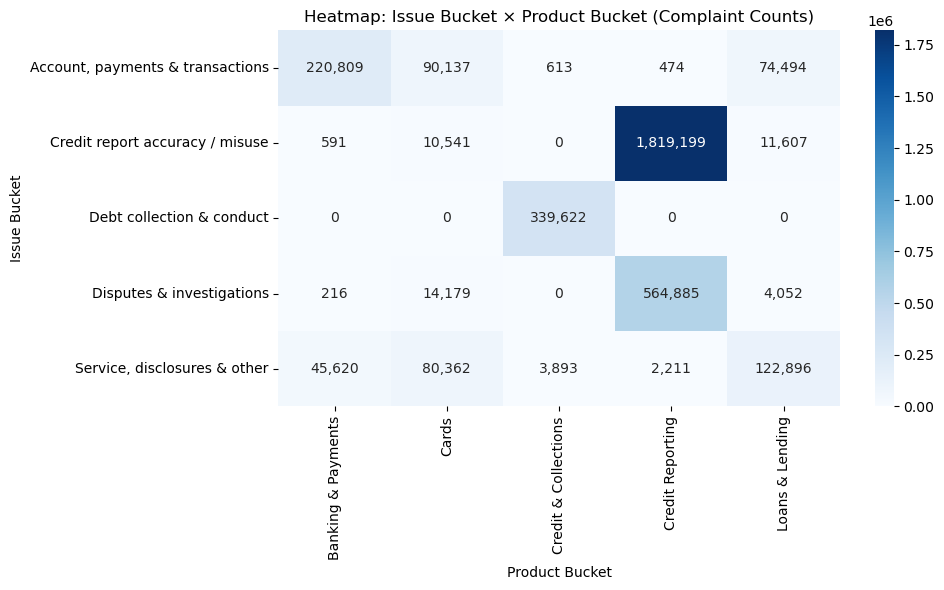

In [17]:
heat_tbl = pd.crosstab(
    df["issue_bucket"],
    df["product_bucket"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat_tbl,
    annot=True,
    fmt=",.0f",
    cmap="Blues"
)

plt.title("Heatmap: Issue Bucket × Product Bucket (Complaint Counts)")
plt.ylabel("Issue Bucket")
plt.xlabel("Product Bucket")
plt.tight_layout()
plt.show()


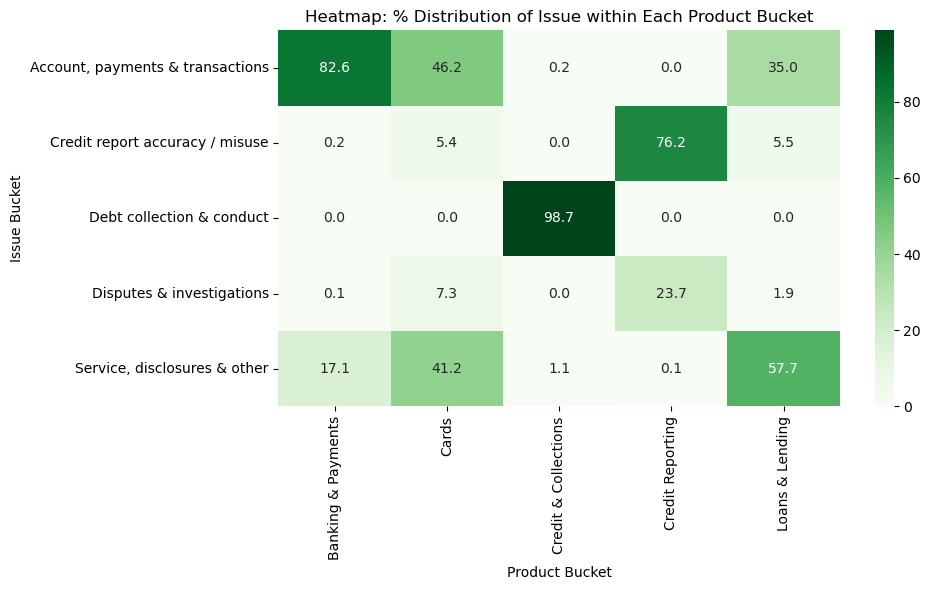

In [18]:
heat_col_pct = (
    heat_tbl.div(heat_tbl.sum(axis=0), axis=1) * 100
).round(2)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat_col_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title("Heatmap: % Distribution of Issue within Each Product Bucket")
plt.ylabel("Issue Bucket")
plt.xlabel("Product Bucket")
plt.tight_layout()
plt.show()



In [19]:
def assign_period(date):
    if pd.isna(date):
        return "Unknown"
    elif date <= pd.Timestamp("2019-12-31"):
        return "Pre-COVID"
    elif date <= pd.Timestamp("2021-12-31"):
        return "COVID"
    else:
        return "Post-COVID"

df["period"] = df["Date received"].apply(assign_period)

df["period"].value_counts()


period
Post-COVID    2785199
COVID          377917
Pre-COVID      243285
Name: count, dtype: int64

In [20]:
df["period"] = pd.Categorical(
    df["period"],
    categories=["Pre-COVID", "COVID", "Post-COVID"],
    ordered=True
)

df["period"].value_counts()


period
Post-COVID    2785199
COVID          377917
Pre-COVID      243285
Name: count, dtype: int64

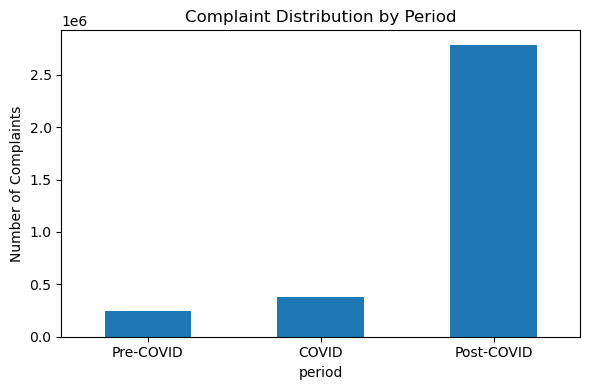

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["period"].value_counts().sort_index().plot(kind="bar")
plt.title("Complaint Distribution by Period")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Correlation Checks

In [22]:
tbl = pd.crosstab(df["product_bucket"], df["issue_bucket"])

chi2, p, dof, expected = chi2_contingency(tbl, correction=False)

n = tbl.to_numpy().sum()
r, k = tbl.shape
cramers_v = np.sqrt((chi2/n) / min(k-1, r-1))

print("Chi-square p-value:", p)
print("Cramér’s V:", round(cramers_v, 4))


### Highly corrrelated - use only issue bucket!

Chi-square p-value: 0.0
Cramér’s V: 0.7171


In [23]:
tbl = pd.crosstab(df["period"], df["issue_bucket"])

chi2, p, dof, expected = chi2_contingency(tbl, correction=False)

n = tbl.to_numpy().sum()
r, k = tbl.shape
cramers_v = np.sqrt((chi2/n) / min(k-1, r-1))

print("Chi-square p-value:", p)
print("Cramér’s V:", round(cramers_v, 4))


Chi-square p-value: 0.0
Cramér’s V: 0.1575


In [24]:
tbl = pd.crosstab(df["period"], df["product_bucket"])
chi2, p, dof, expected = chi2_contingency(tbl, correction=False)

n = tbl.to_numpy().sum()
r, k = tbl.shape
cramers_v = np.sqrt((chi2/n) / min(k-1, r-1))

print("Chi-square p-value:", p)
print("Cramér’s V:", round(cramers_v, 4))


Chi-square p-value: 0.0
Cramér’s V: 0.1642


#### Narrative Cleaning

In [25]:

NARR_COL = "Consumer complaint narrative"

# 1) Use pandas string dtype (safe) — 3.4M is ok
df[NARR_COL] = df[NARR_COL].astype("string")

# 2) Keep raw for traceability
df["narr_raw"] = df[NARR_COL]

# 3) Normalize whitespace + strip (single pass)
df["narr_clean"] = (
    df[NARR_COL]
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# 4) Quick exact replacements for common "fake nulls"
df["narr_clean"] = df["narr_clean"].replace(
    {"nan": pd.NA, "NaN": pd.NA, "None": pd.NA, "none": pd.NA, "NULL": pd.NA, "null": pd.NA}
)

# 5) Convert empty strings to NA
df.loc[df["narr_clean"].eq(""), "narr_clean"] = pd.NA

# 6) Remove placeholders using fullmatch (case-insensitive)
# Keep pattern short & strict for speed
PLACEHOLDER_PAT = r"(?:n/?a|na|none|null|no narrative|not provided|unknown|\.|,|-+|_+)"
ph = df["narr_clean"].str.fullmatch(PLACEHOLDER_PAT, case=False, na=False)
df.loc[ph, "narr_clean"] = pd.NA

# 7) Length features (only where narr_clean exists)
mask = df["narr_clean"].notna()
c = df.loc[mask, "narr_clean"]

df["narr_char_len"] = pd.NA
df["narr_word_len"] = pd.NA

df.loc[mask, "narr_char_len"] = c.str.len()

# FAST word count: regex token count (much faster than split())
df.loc[mask, "narr_word_len"] = c.str.count(r"\b\w+\b")

# 8) Quick checks
print("Percent missing narratives after cleanup:",
      round(df["narr_clean"].isna().mean()*100, 2), "%")

print(df.loc[mask, "narr_word_len"].astype("float").describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))


Percent missing narratives after cleanup: 0.0 %
count    3.406401e+06
mean     1.731670e+02
std      2.191587e+02
min      1.000000e+00
1%       1.100000e+01
5%       2.200000e+01
25%      6.000000e+01
50%      1.140000e+02
75%      2.070000e+02
95%      5.020000e+02
99%      1.021000e+03
max      7.817000e+03
Name: narr_word_len, dtype: float64


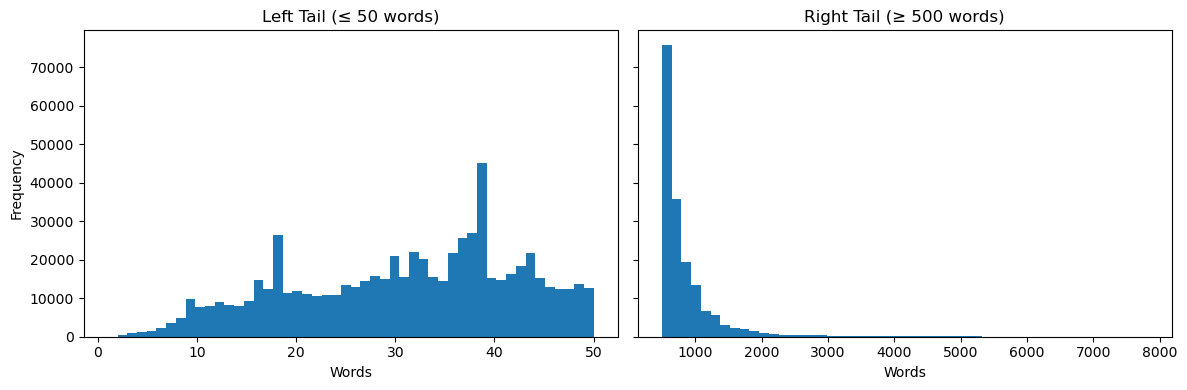

In [29]:


# Define x properly
x = df["narr_word_len"].dropna().astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left tail (≤ 50 words)
left = x[x <= 50]
axes[0].hist(left, bins=50)
axes[0].set_title("Left Tail (≤ 50 words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")

# Right tail (≥ 500 words)
right = x[x >= 500]
axes[1].hist(right, bins=50)
axes[1].set_title("Right Tail (≥ 500 words)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()


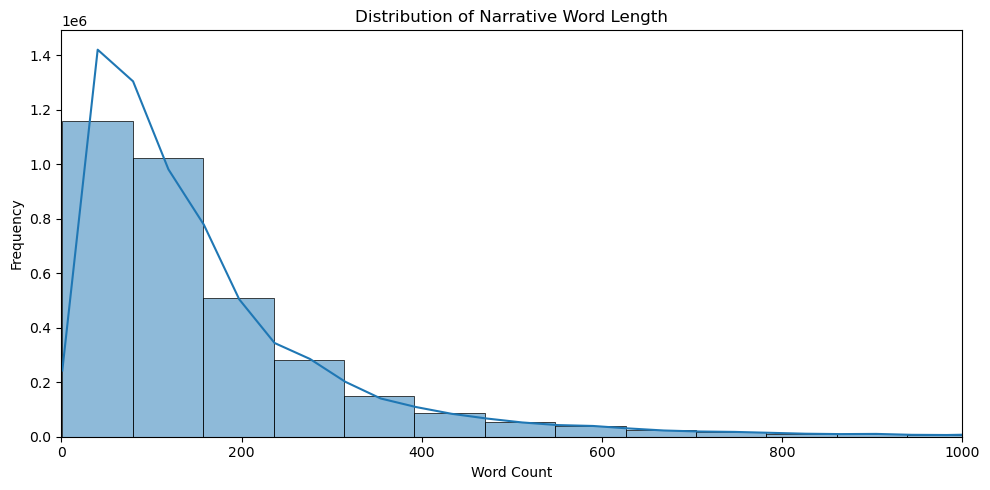

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define x
x = df["narr_word_len"].dropna().astype(float)

plt.figure(figsize=(10, 5))

sns.histplot(
    x,
    bins=100,
    kde=True,          # adds smooth density line
    stat="count"       # show actual counts
)

plt.title("Distribution of Narrative Word Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 1000)     # adjust if needed
plt.tight_layout()
plt.show()


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3406401 entries, 3 to 13019299
Data columns (total 25 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[ns]
 1   Product                       object        
 2   Sub-product                   object        
 3   Issue                         string        
 4   Sub-issue                     string        
 5   Consumer complaint narrative  string        
 6   Company public response       object        
 7   Company                       object        
 8   State                         object        
 9   ZIP code                      object        
 10  Tags                          object        
 11  Consumer consent provided?    object        
 12  Submitted via                 object        
 13  Date sent to company          datetime64[ns]
 14  Company response to consumer  object        
 15  Timely response?              object

#### Drop cols which are not used in the final analysis

In [45]:
drop_cols = [
    "ZIP code",                    # not used; granular 
    "Tags",                        # special populations, not in scope
    "Consumer disputed?",          # 100% missing from 2017
    "Company public response",     # company-side text, not used
    "Submitted via",               # only web channel
    "Date sent to company",        # redundant with Date received
    "Consumer consent provided?"   # narrative already filtered via narr_clean
]

df_final = df.drop(
    columns=[c for c in drop_cols if c in df.columns]
).copy()

In [48]:
df_final.shape

(3406401, 18)

#### Duplicate checks for consumer narrative - single narrative, campaign checks, mass narratives 

Company + Narrative duplicates: 78772
{'Min Date': Timestamp('2018-01-01 00:00:00'), 'Median Date': Timestamp('2024-11-18 00:00:00'), 'Max Date': Timestamp('2025-12-29 00:00:00')}


C:\Users\chait\AppData\Local\Temp\ipykernel_33740\2445761005.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dup_narrative_rows["Year"] = dup_narrative_rows["Date received"].dt.year


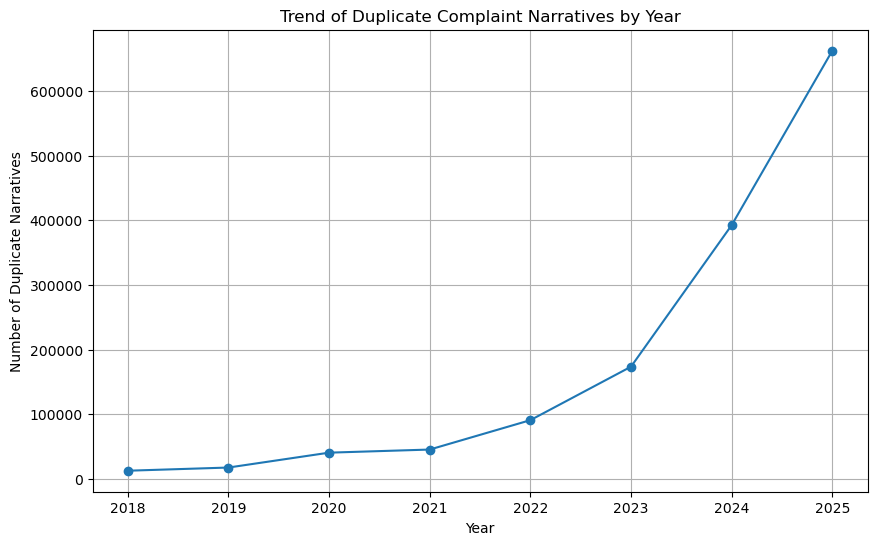

In [15]:
# 5.4.5 Duplicate Company + Narrative

dup_company_narrative = (

    df.groupby(["Company", "Consumer complaint narrative"])

      .size()

      .reset_index(name="count")

      .query("count > 1")

      .sort_values("count", ascending=False)

)
 
print("Company + Narrative duplicates:",

      dup_company_narrative.shape[0])
 
dup_company_narrative.head()
 
 
# Identify rows where narrative appears more than once

dup_narratives = (

    df["Consumer complaint narrative"]

    .value_counts()

    .loc[lambda x: x > 1]

)
 
dup_narrative_rows = df[

    df["Consumer complaint narrative"].isin(dup_narratives.index)

]
 
# Date statistics

date_stats = {

    "Min Date": dup_narrative_rows["Date received"].min(),

    "Median Date": dup_narrative_rows["Date received"].median(),

    "Max Date": dup_narrative_rows["Date received"].max()

}
 
print(date_stats)
 
 
import matplotlib.pyplot as plt
# Extract year
dup_narrative_rows["Year"] = dup_narrative_rows["Date received"].dt.year
# Count duplicates per year

dup_year_trend = (
    dup_narrative_rows.groupby("Year")
    .size()
    .reset_index(name="Duplicate Narratives")

)
 
# Plot trend

plt.figure(figsize=(10,6))
plt.plot(
    dup_year_trend["Year"],
    dup_year_trend["Duplicate Narratives"],
    marker="o"
)
 
plt.title("Trend of Duplicate Complaint Narratives by Year")
plt.xlabel("Year")
plt.ylabel("Number of Duplicate Narratives")
plt.grid(True)
plt.show()
 

In [17]:
dup_company_narrative = (

    df.groupby([ "Consumer complaint narrative"])

      .size()

      .reset_index(name="count")

      .query("count > 1")

      .sort_values("count", ascending=False)

)
 
print("Narrative duplicates:",

      dup_company_narrative.shape[0])
 
dup_company_narrative.head()

Company + Narrative duplicates: 234139


,Consumer complaint narrative,count
1179015,In accordance with the Fair Credit Reporting a...,27076
1318271,My credit reports are inaccurate. These inaccu...,22880
2145061,You have reported inaccurate and unauthorized ...,16720
1921616,"Upon reviewing my credit report, I have identi...",15787
563463,I am writing to have the following information...,12191


In [19]:
df["Consumer complaint narrative"].duplicated().sum()

1201038

In [21]:
dups = df[df["Consumer complaint narrative"].duplicated(keep=False)]
dups[["Consumer complaint narrative"]].head(10)

,Consumer complaint narrative
3,My credit report contains incorrect and mislea...
24,These are not my accounts.
26,I do not recognize the aforementioned accounts...
27,I am formally disputing inaccurate information...
41,Kindly address this issue on my credit report....
71,The Fair Credit Reporting Act ( 15 U.S. Code 1...
101,15USC 1681 a ( d ) ( 2 ) ( A ) ( i ) clearly s...
192,The Fair Credit Reporting Act ( 15 U.S. Code 1...
195,My report includes inquiries that I believe do...
216,I was very surprised and disappointed to disco...


In [29]:
dup_rows = df.duplicated(
    subset=["Consumer complaint narrative", "Product", "Issue","Company","Sub-product","Sub-issue","ZIP code"]
).sum()

print("Duplicate rows:", dup_rows)

Duplicate rows: 349441


In [31]:


campaign_check = (
    df.groupby(["Consumer complaint narrative", "Company"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

campaign_check.head(20)

,Consumer complaint narrative,Company,count
1361437,In accordance with the Fair Credit Reporting a...,"EQUIFAX, INC.",10059
1361443,In accordance with the Fair Credit Reporting a...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",9620
1523132,My credit reports are inaccurate. These inaccu...,"EQUIFAX, INC.",8070
464387,I am filing a complaint against Cash App ( Blo...,"Block, Inc.",7755
1523135,My credit reports are inaccurate. These inaccu...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",7710
1523133,My credit reports are inaccurate. These inaccu...,Experian Information Solutions Inc.,7096
1361438,In accordance with the Fair Credit Reporting a...,Experian Information Solutions Inc.,6957
2452917,You have reported inaccurate and unauthorized ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",6651
2205290,"Upon reviewing my credit report, I have identi...","EQUIFAX, INC.",5625
2205300,"Upon reviewing my credit report, I have identi...","TRANSUNION INTERMEDIATE HOLDINGS, INC.",5570


In [43]:
df["campaign_flag"] = (
    df.groupby(["Consumer complaint narrative", "Company", "Issue","Product"])["Complaint ID"]
      .transform("count")
      .ge(1000)
)

In [44]:
df["campaign_flag"].mean()

0.0632835065513426

In [37]:
campaign_check = (
    df.groupby(["Consumer complaint narrative", "Company", "Issue","Product"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

campaign_check.head(20)

,Consumer complaint narrative,Company,Issue,Product,count
467710,I am filing a complaint against Cash App ( Blo...,"Block, Inc.",Other transaction problem,"Money transfer, virtual currency, or money ser...",7531
2467885,You have reported inaccurate and unauthorized ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Improper use of your report,Credit reporting or other personal consumer re...,6630
2467876,You have reported inaccurate and unauthorized ...,"EQUIFAX, INC.",Improper use of your report,Credit reporting or other personal consumer re...,5486
1370801,In accordance with the Fair Credit Reporting a...,"EQUIFAX, INC.",Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,5155
2219794,"Upon reviewing my credit report, I have identi...","EQUIFAX, INC.",Incorrect information on your report,Credit reporting or other personal consumer re...,5139
2219811,"Upon reviewing my credit report, I have identi...","TRANSUNION INTERMEDIATE HOLDINGS, INC.",Incorrect information on your report,Credit reporting or other personal consumer re...,4942
1370806,In accordance with the Fair Credit Reporting a...,Experian Information Solutions Inc.,Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,4899
1370820,In accordance with the Fair Credit Reporting a...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,4609
1370816,In accordance with the Fair Credit Reporting a...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Improper use of your report,Credit reporting or other personal consumer re...,4542
2467878,You have reported inaccurate and unauthorized ...,Experian Information Solutions Inc.,Improper use of your report,Credit reporting or other personal consumer re...,4523


In [38]:
campaign_check.query("count >= 100").head(20)

,Consumer complaint narrative,Company,Issue,Product,count
467710,I am filing a complaint against Cash App ( Blo...,"Block, Inc.",Other transaction problem,"Money transfer, virtual currency, or money ser...",7531
2467885,You have reported inaccurate and unauthorized ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Improper use of your report,Credit reporting or other personal consumer re...,6630
2467876,You have reported inaccurate and unauthorized ...,"EQUIFAX, INC.",Improper use of your report,Credit reporting or other personal consumer re...,5486
1370801,In accordance with the Fair Credit Reporting a...,"EQUIFAX, INC.",Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,5155
2219794,"Upon reviewing my credit report, I have identi...","EQUIFAX, INC.",Incorrect information on your report,Credit reporting or other personal consumer re...,5139
2219811,"Upon reviewing my credit report, I have identi...","TRANSUNION INTERMEDIATE HOLDINGS, INC.",Incorrect information on your report,Credit reporting or other personal consumer re...,4942
1370806,In accordance with the Fair Credit Reporting a...,Experian Information Solutions Inc.,Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,4899
1370820,In accordance with the Fair Credit Reporting a...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,4609
1370816,In accordance with the Fair Credit Reporting a...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Improper use of your report,Credit reporting or other personal consumer re...,4542
2467878,You have reported inaccurate and unauthorized ...,Experian Information Solutions Inc.,Improper use of your report,Credit reporting or other personal consumer re...,4523


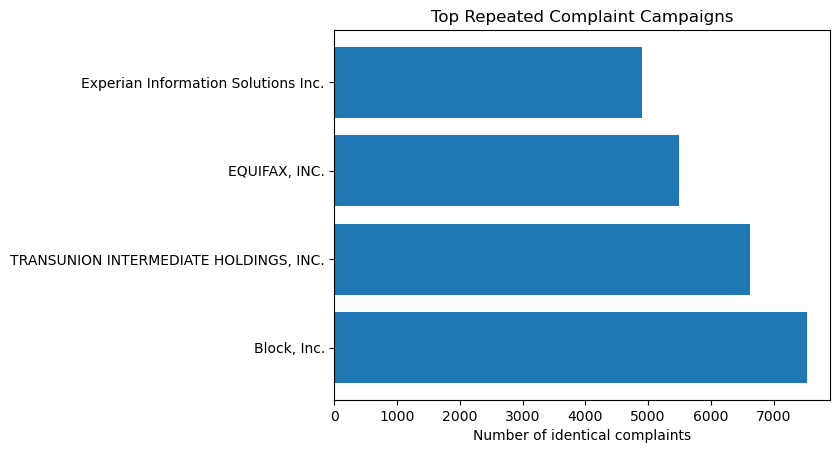

In [41]:
top_campaigns = campaign_check.head(10)

import matplotlib.pyplot as plt

plt.barh(top_campaigns["Company"], top_campaigns["count"])
plt.title("Top Repeated Complaint Campaigns")
plt.xlabel("Number of identical complaints")
plt.show()

In [47]:
campaign_check.query("count >= 1000").shape[0]

90

#### Keyword Failure Type Classification

In [3]:
df_final = pd.read_csv("df_final.csv")
df_final.shape

(3406401, 19)

In [5]:
df_unique_narr = df_final.drop_duplicates(subset=["Consumer complaint narrative", "Product", "Issue", "Sub-issue"]).copy()
df_unique_narr.shape

(2222456, 19)

In [7]:
# =========================================================
# FAILURE TYPE KEYWORDS
# =========================================================

ESCALATION_KEYWORDS = [

"multiple attempts",
"several attempts",
"many attempts",
"repeated attempts",
"multiple requests",
"several requests",
"repeated requests",
"many requests",
"third request",
"second request",
"fourth request",
"numerous requests",

"contacted them multiple times",
"called multiple times",
"called many times",
"contacted repeatedly",
"emailed multiple times",
"sent several emails",
"left multiple messages",
"left several messages",
"multiple phone calls",
"many phone calls",
"several phone calls",

"called again",
"contacted again",
"reached out again",
"tried again",
"attempted again",

"spoke with several representatives",
"spoke with multiple representatives",
"talked to several representatives",
"talked to multiple representatives",

"asked for supervisor",
"requested supervisor",
"asked for manager",
"requested manager",
"speak to supervisor",
"speak to manager",
"requested escalation",
"escalated the issue",
"escalate the issue",
"asked for escalation",
"request escalation",
"requested higher authority",
"asked for someone higher",

"transferred multiple times",
"kept transferring",
"transferred repeatedly",
"passed around",
"sent to another department",
"bounced between departments",
"everyone passed me around",

"no one helped",
"no one could help",
"nobody could help",
"customer service could not help",
"customer service was unable to help",

"not resolved",
"still unresolved",
"issue remains unresolved",
"problem remains unresolved",
"no resolution",
"never resolved",
"still not resolved",
"has not been resolved",
"problem persists",
"issue persists",

"still waiting for resolution",
"waiting for resolution",
"no one resolved the issue",

"case still open",
"case still unresolved",
"case remains open",

"complaint still unresolved",
"issue still pending",

"requested help multiple times",
"asked for help multiple times",
"requested assistance multiple times",

"filed dispute again",
"disputed multiple times",
"repeated dispute",
"multiple disputes",
"disputed several times",
"dispute rejected again",
"resubmitted dispute",
"had to dispute again"
]

COMMUNICATION_KEYWORDS = [

"no response",
"never responded",
"did not respond",
"didn't respond",
"no reply",
"never replied",
"no answer",
"never answered",
"did not answer",

"no call back",
"no callback",
"never called back",
"did not call back",
"never returned my call",
"did not return my call",

"never contacted",
"did not contact",
"never got back to me",
"never got back",
"didn't get back",

"no follow up",
"no follow-up",
"never followed up",
"did not follow up",

"no update",
"never updated me",
"did not update",
"no status update",

"no response for weeks",
"no response for months",

"no communication",
"lack of communication",
"no acknowledgement",
"no acknowledgment",
"no confirmation",
"never confirmed",
"never reached back out",
"never reached out",
"didn't reach out",

"ignored my request",
"ignored my complaint",
"ignored my dispute",

"no reply to my emails",
"did not reply to my emails",

"not explained",
"no explanation",
"never explained",
"did not explain",
"failed to explain",
"refused to explain",
"would not explain",
"unable to explain",
"without explanation",
"no explanation given",
"never gave explanation",

"unclear",
"unclear explanation",
"confusing explanation",
"confusing response",
"vague response",
"vague explanation",
"unclear response",
"not clear",
"unclear answer",

"did not clarify",
"never clarified",
"no clarification",
"no clear answer",

"did not answer my question",
"never answered my question",
"would not answer my question",

"wrong information",
"incorrect information",
"false information",
"misleading",
"misleading information",
"inconsistent information",
"contradictory information",
"conflicting information",
"different answers",
"told me different things",
"changed their story",
"incorrect explanation",
"misrepresented",
"misrepresentation",
"gave wrong information",
"gave incorrect information",

"no notice",
"without notice",
"no warning",
"without warning",
"never notified",
"not notified",
"did not notify",
"failed to notify",
"never informed",
"not informed",
"did not inform",
"failed to inform",
"no written notice",
"no notification",
"no advance notice",

"generic response",
"form letter",
"boilerplate response",
"automated response",
"template response",
"copy paste response",
"copy and paste response",
"standard response",
"canned response",

"rude",
"rude response",
"representative was rude",
"customer service was rude",
"disrespectful",
"dismissive",

"hung up",
"hung up on me",
"they hung up",
"abruptly ended the call",
"ended the call",
"call was disconnected",

"kept me on hold",
"long hold time",
"left on hold",

"refused to speak",
"would not speak",
"refused to discuss",
"would not discuss",
"refused to answer",
"did not provide details",
"refused to provide details"
]

PRODUCT_KEYWORDS = [

"identity theft",
"victim of identity theft",

"account not mine",
"not my account",
"not my accounts",
"account does not belong to me",
"account not authorized",
"account opened without permission",
"account opened fraudulently",

"unauthorized",
"unauthorized charge",
"unauthorized charges",
"unauthorized inquiry",

"fraud",
"fraudulent",
"fraudulent charge",
"fraudulent charges",

"credit report",
"incorrect items on my credit report",
"inaccurate information",
"credit file",
"hard inquiry",
"inquiry not authorized",

"collection account",
"collection agency",
"collection notice",
"collection entry",
"collection tradeline",
"medical collection",
"medical debt",

"charge off",
"late payment is inaccurate",
"remove from my credit report",
"delete from my credit report",
"debt does not belong to me",

"billing error",
"incorrect charge",
"incorrect balance",
"balance is wrong",

"incorrect late fee",
"late fee error",
"late fee charged incorrectly",

"charged incorrectly",
"charged twice",
"double charge",

"fraud claim",
"fraud investigation",
"fraud claim denied",

"transaction dispute",
"billing dispute",

"debt collector",
"validation of the debt",
"validation of debt",
"debt validation",
"verify this debt",
"prove this debt",

"credit bureau",
"credit bureaus",
"credit reporting agency",
"reporting agency",

"reporting inaccurate",
"incorrect reporting",
"false reporting",
"reporting errors",

"wrong account",
"incorrect account",
"wrong account number",

"payment applied incorrectly",
"payment misapplied",
"payment not applied",
"payment applied to wrong account",

"loan servicing",
"mortgage servicing",

"wrong debt amount",
"collection error",
"debt collection error",

"incorrect account status",
"account reported incorrectly",

"loan balance incorrect",
"mortgage balance incorrect",

"incorrect interest",
"wrong interest charged",

"account closed without notice",
"account closed unexpectedly"
]

#### Assign a hierarchy for failure types for keyword classification 

In [9]:
def classify_failure_keyword(text):

    text = str(text).lower()

    esc_score = sum(k in text for k in ESCALATION_KEYWORDS)
    comm_score = sum(k in text for k in COMMUNICATION_KEYWORDS)
    prod_score = sum(k in text for k in PRODUCT_KEYWORDS)

    if esc_score > 0:
        return "Escalation Failure"

    elif comm_score > 0:
        return "Communication Failure"

    elif prod_score > 0:
        return "Product/Process Failure"

    else:
        return "Other Failure"

df_final["failure_type_keyword"] = df_final["narr_clean"].apply(classify_failure_keyword)
df_final["failure_type_keyword"].value_counts(normalize=True) * 100

failure_type_keyword
Product/Process Failure    60.332269
Other Failure              21.743535
Communication Failure      13.666653
Escalation Failure          4.257543
Name: proportion, dtype: float64

#### Check data imbalance and trim narratives before moving to final modeling phase

In [10]:
# keep only medium-length narratives for LLM
MIN_WORDS = 20
MAX_WORDS = 500

df_llm = df_final[
    (df_final["narr_word_len"] >= MIN_WORDS) &
    (df_final["narr_word_len"] <= MAX_WORDS)
].copy()

print("Original rows:", len(df_final))
print("Rows kept for LLM:", len(df_llm))
print("Rows removed:", len(df_final) - len(df_llm))
print("Percent kept:", round(len(df_llm) / len(df_final) * 100, 2), "%")

Original rows: 3406401
Rows kept for LLM: 3095353
Rows removed: 311048
Percent kept: 90.87 %


In [ ]:
# df_llm.to_parquet("df_llm.parquet", index=False)
# print("Dataset saved as CSV.")

#### ML Techniques to classify faliure type

In [15]:
df_ml = pd.read_parquet("df_llm.parquet")
df_ml.shape
# Keep only columns needed for ML
drop_cols = [
    "ZIP code",
    "Tags",
    "Consumer disputed?",
    "Company public response",
    "Submitted via",
    "Date sent to company",
    "Consumer consent provided?",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "State",
    "Complaint ID",
    "narr_raw",
    "narr_char_len",
    "campaign_flag",
    "Timely response?",
    "Company response to consumer"
]

df_ml = df_ml.drop(columns=[c for c in drop_cols if c in df_ml.columns], errors="ignore").copy()

# Deduplicate normalized narratives
df_ml2 = df_ml.drop_duplicates(subset=["narr_clean"]).copy()

# Features and target
X = df_ml2[["narr_clean", "narr_word_len"]].copy()
y = df_ml2["failure_type_keyword"].copy()

# Train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))

Train: 1348142
Validation: 288888
Test: 288888

Train class distribution:
failure_type_keyword
Product/Process Failure    0.5613
Other Failure              0.2620
Communication Failure      0.1314
Escalation Failure         0.0453
Name: proportion, dtype: float64


In [16]:
#preprocessor
text_col = "narr_clean"
num_cols = ["narr_word_len"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.90,
                sublinear_tf=True
            ),
            text_col
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MaxAbsScaler())
            ]),
            num_cols
        )
    ],
    remainder="drop"
)

In [17]:
#Evaluate model - Test, train and Validation
def evaluate_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Metrics dictionary
    results = {
        "model": name,

        # TRAIN METRICS
        "train_accuracy": accuracy_score(y_train, train_pred),
        "train_macro_f1": f1_score(y_train, train_pred, average="macro"),
        "train_weighted_f1": f1_score(y_train, train_pred, average="weighted"),

        # VALIDATION METRICS
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_weighted_f1": f1_score(y_val, val_pred, average="weighted"),

        # TEST METRICS
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro"),
        "test_weighted_f1": f1_score(y_test, test_pred, average="weighted")
    }

    # PRINT REPORTS
    print(f"\n{'='*25} {name} {'='*25}")

    print("\nTRAIN REPORT")
    print(classification_report(y_train, train_pred))

    print("\nVALIDATION REPORT")
    print(classification_report(y_val, val_pred))

    print("\nTEST REPORT")
    print(classification_report(y_test, test_pred))

    return results, model, train_pred, val_pred, test_pred

In [37]:
# Model 1: Logistic Regression with class_weight='balanced'
#time to run 3700 sec

lr_balanced = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lr_balanced_results, lr_balanced_fitted, lr_train_pred, lr_val_pred, lr_test_pred = evaluate_model(
    "LogisticRegression_balanced",
    lr_balanced,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)


========================= LogisticRegression_balanced =========================

TRAIN REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.92      0.94      0.93    177136
     Escalation Failure       0.81      0.96      0.88     61127
          Other Failure       0.94      0.98      0.96    353179
Product/Process Failure       0.99      0.95      0.97    756700

               accuracy                           0.96   1348142
              macro avg       0.92      0.96      0.94   1348142
           weighted avg       0.96      0.96      0.96   1348142


VALIDATION REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.90      0.93      0.91     37958
     Escalation Failure       0.78      0.92      0.85     13098
          Other Failure       0.93      0.98      0.96     75681
Product/Process Failure       0.99      0.95      0.97    162151

               accuracy             

In [25]:
# Model 2: LinearSVC with class_weight='balanced' 2773

svm_balanced = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(class_weight="balanced", random_state=42, dual="auto"))
])

svm_balanced_results, svm_balanced_fitted, svm_val_pred, svm_test_pred, svm_train_pred = evaluate_model(
    "LinearSVC_balanced",
    svm_balanced,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)


========================= LinearSVC_balanced =========================

TRAIN REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.96      0.94      0.95    177136
     Escalation Failure       0.94      0.93      0.93     61127
          Other Failure       0.96      0.99      0.98    353179
Product/Process Failure       0.99      0.98      0.99    756700

               accuracy                           0.98   1348142
              macro avg       0.96      0.96      0.96   1348142
           weighted avg       0.98      0.98      0.98   1348142


VALIDATION REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.95      0.93      0.94     37958
     Escalation Failure       0.91      0.90      0.90     13098
          Other Failure       0.96      0.99      0.97     75681
Product/Process Failure       0.99      0.98      0.98    162151

               accuracy                      

In [27]:
# Model 3: LinearSVC with inverse-frequency weights

freq = y_train.value_counts(normalize=True)
inverse_freq_weights = {cls: 1 / freq[cls] for cls in freq.index}

svm_inverse = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(class_weight=inverse_freq_weights, random_state=42, dual="auto"))
])

svm_inverse_results, svm_inverse_fitted, svm_inverse_val_pred,svm_inverse_test_pred, svm_inverse_train_pred = evaluate_model(
    "LinearSVC_inverse_frequency",
    svm_inverse,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)


========================= LinearSVC_inverse_frequency =========================

TRAIN REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.96      0.94      0.95    177136
     Escalation Failure       0.95      0.92      0.94     61127
          Other Failure       0.97      0.99      0.98    353179
Product/Process Failure       0.99      0.99      0.99    756700

               accuracy                           0.98   1348142
              macro avg       0.97      0.96      0.96   1348142
           weighted avg       0.98      0.98      0.98   1348142


VALIDATION REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.95      0.92      0.94     37958
     Escalation Failure       0.92      0.89      0.90     13098
          Other Failure       0.96      0.99      0.97     75681
Product/Process Failure       0.99      0.98      0.98    162151

               accuracy             

In [29]:
# Model 4: SMOTE + LinearSVC
# Use a sample only because full SMOTE is too expensive

sample_df = X_train.copy()
sample_df["target"] = y_train.values

# Cap each class at 20,000 for SMOTE experiment
sampled = (
    sample_df.groupby("target", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 20000), random_state=42))
    .reset_index(drop=True)
)

X_train_sample = sampled[["narr_clean", "narr_word_len"]]
y_train_sample = sampled["target"]

print("Before SMOTE sample counts:")
print(y_train_sample.value_counts())

# Fit-transform with same preprocessor
X_train_transformed = preprocessor.fit_transform(X_train_sample, y_train_sample)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train_sample)

print("\nAfter SMOTE counts:")
print(pd.Series(y_train_resampled).value_counts())

# Train SVM on SMOTE output
svm_smote = LinearSVC(random_state=42, dual="auto")
svm_smote.fit(X_train_resampled, y_train_resampled)

# Predictions
smote_train_pred = svm_smote.predict(X_train_resampled)

X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

smote_val_pred = svm_smote.predict(X_val_transformed)
smote_test_pred = svm_smote.predict(X_test_transformed)

# Results dictionary
smote_results = {
    "model": "SMOTE_LinearSVC",

    "train_accuracy": accuracy_score(y_train_resampled, smote_train_pred),
    "train_macro_f1": f1_score(y_train_resampled, smote_train_pred, average="macro"),
    "train_weighted_f1": f1_score(y_train_resampled, smote_train_pred, average="weighted"),

    "val_accuracy": accuracy_score(y_val, smote_val_pred),
    "val_macro_f1": f1_score(y_val, smote_val_pred, average="macro"),
    "val_weighted_f1": f1_score(y_val, smote_val_pred, average="weighted"),

    "test_accuracy": accuracy_score(y_test, smote_test_pred),
    "test_macro_f1": f1_score(y_test, smote_test_pred, average="macro"),
    "test_weighted_f1": f1_score(y_test, smote_test_pred, average="weighted")
}

print("\n========================= SMOTE + LinearSVC =========================")

print("\nTRAIN REPORT")
print(classification_report(y_train_resampled, smote_train_pred))

print("\nVALIDATION REPORT")
print(classification_report(y_val, smote_val_pred))

print("\nTEST REPORT")
print(classification_report(y_test, smote_test_pred))

C:\Users\chait\AppData\Local\Temp\ipykernel_42740\1218765297.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 20000), random_state=42))


Before SMOTE sample counts:
target
Communication Failure      20000
Escalation Failure         20000
Other Failure              20000
Product/Process Failure    20000
Name: count, dtype: int64

After SMOTE counts:
target
Communication Failure      20000
Escalation Failure         20000
Other Failure              20000
Product/Process Failure    20000
Name: count, dtype: int64

========================= SMOTE + LinearSVC =========================

TRAIN REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.99      0.99      0.99     20000
     Escalation Failure       0.99      0.99      0.99     20000
          Other Failure       0.99      1.00      0.99     20000
Product/Process Failure       0.99      0.99      0.99     20000

               accuracy                           0.99     80000
              macro avg       0.99      0.99      0.99     80000
           weighted avg       0.99      0.99      0.99     80000


VALIDATION R

In [33]:
#Model 5: NB with alpha 0.5

nb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", MultinomialNB(alpha=0.5))
])

nb_results, nb_fitted, nb_val_pred,nb_train_pred, nb_test_pred = evaluate_model(
    "MultinomialNB_alpha_0.5",
    nb_pipeline,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)


========================= MultinomialNB_alpha_0.5 =========================

TRAIN REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.73      0.32      0.45    177136
     Escalation Failure       0.48      0.30      0.37     61127
          Other Failure       0.55      0.79      0.65    353179
Product/Process Failure       0.82      0.78      0.80    756700

               accuracy                           0.70   1348142
              macro avg       0.65      0.55      0.57   1348142
           weighted avg       0.72      0.70      0.69   1348142


VALIDATION REPORT
                         precision    recall  f1-score   support

  Communication Failure       0.73      0.32      0.44     37958
     Escalation Failure       0.47      0.29      0.36     13098
          Other Failure       0.54      0.79      0.64     75681
Product/Process Failure       0.82      0.78      0.80    162151

               accuracy                 

In [39]:
#Compare all models in one table

results_df = pd.DataFrame([
    lr_balanced_results,
    svm_balanced_results,
    svm_inverse_results,
    smote_results,
    nb_results
]).sort_values(by=["val_macro_f1", "test_macro_f1"], ascending=False)

print(results_df)

                         model  train_accuracy  train_macro_f1  \
2  LinearSVC_inverse_frequency        0.978842        0.963682   
1           LinearSVC_balanced        0.977582        0.962366   
0  LogisticRegression_balanced        0.960000        0.936550   
3              SMOTE_LinearSVC        0.990387        0.990386   
4      MultinomialNB_alpha_0.5        0.702097        0.566136   

   train_weighted_f1  val_accuracy  val_macro_f1  val_weighted_f1  \
2           0.978767      0.972186      0.949735         0.972073   
1           0.977539      0.971283      0.949149         0.971224   
0           0.960527      0.952099      0.921398         0.952785   
3           0.990386      0.896493      0.858414         0.898801   
4           0.694574      0.700323      0.561396         0.692473   

   test_accuracy  test_macro_f1  test_weighted_f1  
2       0.972401       0.950177          0.972297  
1       0.971598       0.949998          0.971543  
0       0.952317       0.921935 

Multiple models were evaluated, including Logistic Regression, LinearSVC, Multinomial Naive Bayes, and SMOTE-based approaches. Among these, LinearSVC consistently achieved the best performance, with a macro F1 score of approximately 0.95 and accuracy of 97.2% on the test set. Different class weighting strategies (balanced, inverse frequency, and computed class weights) produced nearly identical results, indicating robustness 
to class imbalance. Logistic Regression achieved slightly lower performance (macro F1 ≈ 0.92), while Multinomial Naive Bayes performed significantly worse (macro F1 ≈ 0.56), likely due to its independence assumptions. SMOTE-based oversampling degraded performance, confirming that synthetic sampling is not effective for high-dimensional sparse TF-IDF representations. Based on both performance and computational efficiency, LinearSVC was selected as the final model. The model does not exhibit signs of overfitting, as validation and test performance are nearly identical (macro F1 ≈ 0.95). This indicates strong generalization to unseen data. Additionally, the use of a linear model with regularization (LinearSVC) and a large training dataset further reduces the risk of overfitting.

#### Select Final ML model 

In [42]:
#Pick final model
# Based on your earlier results, this should be LinearSVC

best_model = svm_inverse_fitted
best_model_name = "LinearSVC_inverse_frequency"

print("Selected final model:", best_model_name)

Selected final model: LinearSVC_inverse_frequency


#### Calculate low confidence classifications

In [44]:
#Extract low-confidence cases from LinearSVC
#LinearSVC does not return probabilities, so use margin

def get_margin_confidence(pipe, X_input):
    """
    For LinearSVC:
    - pred_labels: predicted class labels
    - max_margin: top decision score
    - margin_gap: difference between top-1 and top-2 decision scores
    - decision_scores: raw decision function output
    """
    X_transformed = pipe.named_steps["prep"].transform(X_input)
    clf = pipe.named_steps["model"]

    decision_scores = clf.decision_function(X_transformed)

    # Handle binary vs multiclass
    if decision_scores.ndim == 1:
        # binary case
        pred_idx = (decision_scores > 0).astype(int)
        pred_labels = clf.classes_[pred_idx]
        max_margin = np.abs(decision_scores)
        margin_gap = np.abs(decision_scores)
    else:
        # multiclass case
        pred_idx = np.argmax(decision_scores, axis=1)
        pred_labels = clf.classes_[pred_idx]

        top2 = np.sort(decision_scores, axis=1)[:, -2:]
        max_margin = top2[:, 1]
        margin_gap = top2[:, 1] - top2[:, 0]

    return pred_labels, max_margin, margin_gap, decision_scores

In [46]:
# Choose a threshold for LLM routing

val_pred_labels, val_max_margin, val_margin_gap, _ = get_margin_confidence(best_model, X_val)

low_conf_val = X_val.copy()
low_conf_val["true_label"] = y_val.values
low_conf_val["pred_label"] = val_pred_labels
low_conf_val["max_margin"] = val_max_margin
low_conf_val["margin_gap"] = val_margin_gap

print(low_conf_val[["pred_label", "margin_gap"]].head())
print(low_conf_val["margin_gap"].describe())

                      pred_label  margin_gap
183190   Product/Process Failure    2.354392
1678856    Communication Failure    3.572107
2936661            Other Failure    1.485122
1501849  Product/Process Failure    5.055763
3062428            Other Failure    2.024558
count    288888.000000
mean          3.001879
std           1.723999
min           0.000018
25%           1.822268
50%           2.670306
75%           3.919429
max          31.805726
Name: margin_gap, dtype: float64


#### Decide the sweet spot for margin%

In [47]:
low_conf_val["is_error"] = (low_conf_val["true_label"] != low_conf_val["pred_label"]).astype(int)

for q in [0.05,0.06,0.07,0.08,0.09, 0.10, 0.15, 0.20]:
    thr = low_conf_val["margin_gap"].quantile(q)
    subset = low_conf_val[low_conf_val["margin_gap"] <= thr]
    error_rate = subset["is_error"].mean()
    coverage = len(subset) / len(low_conf_val)
    print(f"Bottom {int(q*100)}% | threshold={thr:.4f} | rows={len(subset)} | coverage={coverage:.3f} | error_rate={error_rate:.3f}")

Bottom 5% | threshold=0.7681 | rows=14445 | coverage=0.050 | error_rate=0.284
Bottom 6% | threshold=0.8690 | rows=17334 | coverage=0.060 | error_rate=0.257
Bottom 7% | threshold=0.9583 | rows=20223 | coverage=0.070 | error_rate=0.234
Bottom 8% | threshold=1.0410 | rows=23111 | coverage=0.080 | error_rate=0.216
Bottom 9% | threshold=1.1125 | rows=26000 | coverage=0.090 | error_rate=0.200
Bottom 10% | threshold=1.1796 | rows=28889 | coverage=0.100 | error_rate=0.187
Bottom 15% | threshold=1.4456 | rows=43334 | coverage=0.150 | error_rate=0.140
Bottom 20% | threshold=1.6469 | rows=57778 | coverage=0.200 | error_rate=0.113


In [48]:
threshold = low_conf_val["margin_gap"].quantile(0.10)  
llm_candidates = low_conf_val[low_conf_val["margin_gap"] <= threshold].copy()

print("Rows sent to LLM:", len(llm_candidates))
print(llm_candidates[["true_label", "pred_label", "margin_gap"]].head())

Rows sent to LLM: 28889
                    true_label               pred_label  margin_gap
1958369  Communication Failure  Product/Process Failure    1.086694
957155   Communication Failure    Communication Failure    0.165378
1079947          Other Failure            Other Failure    0.023037
1002725          Other Failure            Other Failure    1.034081
1879305          Other Failure            Other Failure    0.924496


In [49]:
val_df = X_val.copy()

val_df["true_label"] = y_val.values
val_df["ml_pred"] = val_pred_labels
val_df["margin_gap"] = val_margin_gap

In [50]:
threshold = val_df["margin_gap"].quantile(0.08)
val_df["use_llm"] = val_df["margin_gap"] <= threshold
# val_df["final_pred"] = val_df["ml_pred"]
val_df["prediction_source"] = "ML"
val_df.shape

(288888, 7)

In [58]:
#val_df.to_parquet("val_df1.parquet", index=False)

In [62]:
#val_df.to_parquet("val_df.parquet", index=False)
val_df = pd.read_parquet("val_df1.parquet")
val_df.head()

,narr_clean,narr_word_len,true_label,ml_pred,margin_gap,use_llm,prediction_source
0,"XXXX XXXX, AND EQUIFAX ARE TO VIOLATING MY RIG...",46,Product/Process Failure,Product/Process Failure,2.354392,False,ML
1,On XX/XX/XXXX I got a call from Someone from t...,450,Communication Failure,Communication Failure,3.572107,False,ML
2,I came in good faith as an applicant and appli...,37,Other Failure,Other Failure,1.485122,False,ML
3,This is my formal complaint against Amerifinan...,262,Product/Process Failure,Product/Process Failure,5.055763,False,ML
4,This individual XXXX XXXX pulled my credit sco...,46,Other Failure,Other Failure,2.024558,False,ML


In [66]:
#Create LLM queue from low-confidence rows

llm_queue_val = val_df[val_df["use_llm"]].copy().reset_index()
llm_queue_val = llm_queue_val.rename(columns={"index": "orig_idx"})

print("Rows going to LLM:", len(llm_queue_val))
llm_queue_val[["orig_idx", "narr_clean", "ml_pred", "margin_gap"]].head()

Rows going to LLM: 23111


,orig_idx,narr_clean,ml_pred,margin_gap
0,24,"I ordered a dress from XXXX XXXX, XXXX XXXX fo...",Communication Failure,0.165378
1,34,On XX/XX/XXXX I booked a rental vehicle from X...,Other Failure,0.023037
2,38,"On XX/XX/2023 ( over a year ago ), the consoli...",Other Failure,1.034081
3,40,I had a prepaid American Express card that was...,Other Failure,0.924496
4,69,"On XX/XX/2024, the credit card collections tea...",Communication Failure,1.018999


#### LLM Classification for low confidence - 8% margin

In [122]:
# Build prompt for each row for LLM classification

def build_llm_prompt(row):
    return f"""
You are classifying a CFPB complaint narrative into exactly one category:

1. Communication Failure
2. Escalation Failure
3. Product/Process Failure
4. Other Failure

Definitions:
- Communication Failure: lack of response, unclear explanations, incorrect information, poor communication, no notice, rude or dismissive interaction.
- Escalation Failure: repeated attempts, unresolved case after multiple contacts, requests for supervisor/manager, bounced across departments, issue persists.
- Product/Process Failure: billing error, fraud, unauthorized account/charge, incorrect reporting, debt validation issue, payment processing issue, account/process failure.
- Other Failure: complaint does not clearly fit the above categories.

Return JSON only in this format:
{{"label": "<one of the 4 labels>", "confidence": <0 to 1>, "reason": "<short reason>"}}

Narrative:
\"\"\"{row['narr_clean']}\"\"\"
""".strip()

llm_queue_val["llm_prompt"] = llm_queue_val.apply(build_llm_prompt, axis=1)

llm_queue_val[["orig_idx", "ml_pred", "margin_gap", "llm_prompt"]].head(2)

,orig_idx,ml_pred,margin_gap,llm_prompt
0,24,Communication Failure,0.165378,You are classifying a CFPB complaint narrative...
1,34,Other Failure,0.023037,You are classifying a CFPB complaint narrative...


In [156]:
def call_llm(prompt):
    try:
        response = client.responses.create(
            model="gpt-4.1-mini",
            temperature=0,
            input=prompt,
            text={
                "format": {
                    "type": "json_schema",
                    "name": "failure_label",
                    "strict": True,
                    "schema": {
                        "type": "object",
                        "properties": {
                            "label": {
                                "type": "string",
                                "enum": [
                                    "Communication Failure",
                                    "Escalation Failure",
                                    "Product/Process Failure",
                                    "Other Failure"
                                ]
                            },
                            "confidence": {
                                "type": "number"
                            },
                            "reason": {
                                "type": "string"
                            }
                        },
                        "required": ["label", "confidence", "reason"],
                        "additionalProperties": False
                    }
                }
            }
        )

        usage = response.usage   

        return json.loads(response.output_text), usage

    except Exception as e:
        return {
            "label": None,
            "confidence": None,
            "reason": f"ERROR: {str(e)}"
        }, None

#### Group LLM classification - full dataset

In [158]:
def build_llm_group_prompt(group_df):
    items = []
    for _, row in group_df.iterrows():
        items.append(
            f"""
ID: {int(row['orig_idx'])}
Narrative:
\"\"\"{row['narr_clean']}\"\"\"
""".strip()
        )

    joined_items = "\n\n---\n\n".join(items)

    prompt = f"""
You are classifying a CFPB complaint narrative into exactly one category:

1. Communication Failure
2. Escalation Failure
3. Product/Process Failure
4. Other Failure

Definitions:
- Communication Failure: lack of response, unclear explanations, incorrect information...
- Escalation Failure: repeated attempts, unresolved case...
- Product/Process Failure: billing error, fraud, incorrect reporting...
- Other Failure: none of the above

Return JSON array:
[
  {{"orig_idx": 123, "label": "...", "confidence": 0.9, "reason": "short"}}
]

Classify ALL items below:

{joined_items}
"""
    return prompt

In [160]:
def call_llm_group(prompt):
    try:
        response = client.responses.create(
            model="gpt-4.1-mini",
            temperature=0,
            input=prompt
        )

        usage = response.usage

        raw_output = response.output_text

        # DEBUG (first run only)
        print("RAW OUTPUT SAMPLE:\n", raw_output[:300])

        try:
            parsed = json.loads(raw_output)
        except Exception as parse_error:
            print("JSON PARSE ERROR:", str(parse_error))
            return [], usage

        return parsed, usage

    except Exception as e:
        print("LLM ERROR:", str(e))
        return [], None

In [162]:
experiment_df = (
    llm_queue_val
    .sort_values("margin_gap")
    .head(50)
    .copy()
    .reset_index(drop=True)
)

print("Experiment rows:", len(experiment_df))
experiment_df[["orig_idx", "ml_pred", "margin_gap"]].head()

Experiment rows: 50


,orig_idx,ml_pred,margin_gap
0,79864,Communication Failure,0.000018
1,157159,Escalation Failure,0.000041
2,101971,Communication Failure,0.000042
3,20239,Other Failure,0.000103
4,255569,Communication Failure,0.000220


In [164]:
def chunk_dataframe(df, chunk_size):
    for start in range(0, len(df), chunk_size):
        yield df.iloc[start:start + chunk_size]

#### Mini-batch LLM classifications - 10 rows

In [166]:
def run_minibatch_experiment(experiment_df, batch_size=10):
    total_input_tokens = 0
    total_output_tokens = 0
    outputs = []

    start_time = time.time()
    call_count = 0

    for batch_df in chunk_dataframe(experiment_df, batch_size):
        call_count += 1

        prompt = build_llm_group_prompt(batch_df)
        results, usage = call_llm_group(prompt)

        if usage:
            total_input_tokens += getattr(usage, "input_tokens", 0)
            total_output_tokens += getattr(usage, "output_tokens", 0)

        for item in results:
            outputs.append({
                "orig_idx": item.get("orig_idx"),
                "minibatch_label": item.get("label"),
                "minibatch_confidence": item.get("confidence"),
                "minibatch_reason": item.get("reason")
            })

        print(f"Mini-batch call {call_count} completed")

    elapsed = time.time() - start_time

    results_df = pd.DataFrame(outputs)

    summary = {
        "method": f"minibatch_{batch_size}",
        "rows": len(experiment_df),
        "calls_made": call_count,
        "elapsed_sec": elapsed,
        "input_tokens": total_input_tokens,
        "output_tokens": total_output_tokens
    }

    return results_df, summary

In [168]:
def run_all_at_once_experiment(experiment_df):
    start_time = time.time()

    prompt = build_llm_group_prompt(experiment_df)
    results, usage = call_llm_group(prompt)

    elapsed = time.time() - start_time

    outputs = []
    for item in results:
        outputs.append({
            "orig_idx": item.get("orig_idx"),
            "all_at_once_label": item.get("label"),
            "all_at_once_confidence": item.get("confidence"),
            "all_at_once_reason": item.get("reason")
        })

    results_df = pd.DataFrame(outputs)

    summary = {
        "method": "all_at_once_50",
        "rows": len(experiment_df),
        "calls_made": 1,
        "elapsed_sec": elapsed,
        "input_tokens": getattr(usage, "input_tokens", 0) if usage else 0,
        "output_tokens": getattr(usage, "output_tokens", 0) if usage else 0
    }

    return results_df, summary

In [173]:
minibatch_results_df, minibatch_summary = run_minibatch_experiment(experiment_df, batch_size=10)
all_once_results_df, all_once_summary = run_all_at_once_experiment(experiment_df)

print("\nMini-batch summary:")
print(minibatch_summary)


print("\nAll-at-once summary:")
print(all_once_summary)

RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 79864,
    "label": "Communication Failure",
    "confidence": 0.95,
    "reason": "The complaint describes lack of clear updates and only receiving automated or generic responses without resolution."
  },
  {
    "orig_idx": 157159,
    "label": "Escalation Failure",
    "conf
Mini-batch call 1 completed
RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 105292,
    "label": "Communication Failure",
    "confidence": 0.85,
    "reason": "The complaint centers on unclear and suspicious demands for documentation and lack of trust in the communication from USAA."
  },
  {
    "orig_idx": 245458,
    "label": "Escalation Failure",

Mini-batch call 2 completed
RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 76956,
    "label": "Product/Process Failure",
    "confidence": 0.9,
    "reason": "The complaint concerns inaccurate and contradictory credit reporting data, which is a product/process failure."
  },
  {
    "orig_idx": 253183,
    "label": "Communication Fa

#### Compare between group and mini-batch

In [175]:
compare_df = (
    experiment_df[["orig_idx", "true_label", "ml_pred", "margin_gap"]]
    .merge(minibatch_results_df, on="orig_idx", how="left")
    .merge(all_once_results_df, on="orig_idx", how="left")
)

compare_df["same_label"] = (
    compare_df["minibatch_label"] == compare_df["all_at_once_label"]
)

compare_df["minibatch_correct"] = (
    compare_df["minibatch_label"] == compare_df["true_label"]
)

compare_df["all_at_once_correct"] = (
    compare_df["all_at_once_label"] == compare_df["true_label"]
)

agreement_rate = compare_df["same_label"].mean()

minibatch_acc = compare_df["minibatch_correct"].mean()
all_once_acc = compare_df["all_at_once_correct"].mean()

print("Agreement rate:", round(agreement_rate, 4))
print("Mini-batch accuracy:", round(minibatch_acc, 4))
print("All-at-once accuracy:", round(all_once_acc, 4))

Agreement rate: 0.8
Mini-batch accuracy: 0.44
All-at-once accuracy: 0.34


In [181]:
# --- LLM vs ML agreement / override diagnostics ---

# If your compare_df already exists and includes:
# orig_idx, true_label, ml_pred, minibatch_label, all_at_once_label
# this will work directly.

diag_df = compare_df.copy()


# 1) Agreement with ML
diag_df["minibatch_agrees_with_ml"] = diag_df["minibatch_label"] == diag_df["ml_pred"]
diag_df["all_once_agrees_with_ml"] = diag_df["all_at_once_label"] == diag_df["ml_pred"]

# 2) Override rate = LLM changed the ML prediction
diag_df["minibatch_overrides_ml"] = diag_df["minibatch_label"] != diag_df["ml_pred"]
diag_df["all_once_overrides_ml"] = diag_df["all_at_once_label"] != diag_df["ml_pred"]

# 3) Was the ML prediction correct vs reference label?
diag_df["ml_correct"] = diag_df["ml_pred"] == diag_df["true_label"]
print("ML accuracy vs reference:", round(diag_df["ml_correct"].mean(), 4))
# 4) Did LLM fix ML or hurt ML?
diag_df["minibatch_correct"] = diag_df["minibatch_label"] == diag_df["true_label"]
diag_df["all_at_once_correct"] = diag_df["all_at_once_label"] == diag_df["true_label"]

diag_df["minibatch_fixed_ml"] = (
    (~diag_df["ml_correct"]) & (diag_df["minibatch_correct"])
)

diag_df["minibatch_hurt_ml"] = (
    (diag_df["ml_correct"]) & (~diag_df["minibatch_correct"])
)

diag_df["all_once_fixed_ml"] = (
    (~diag_df["ml_correct"]) & (diag_df["all_at_once_correct"])
)

diag_df["all_once_hurt_ml"] = (
    (diag_df["ml_correct"]) & (~diag_df["all_at_once_correct"])
)

# 5) Summary table
llm_ml_summary = pd.DataFrame([
    {
        "method": "mini_batch",
        "agreement_with_ml": round(diag_df["minibatch_agrees_with_ml"].mean(), 4),
        "override_rate": round(diag_df["minibatch_overrides_ml"].mean(), 4),
        "accuracy_vs_reference": round(diag_df["minibatch_correct"].mean(), 4),
        "fixed_ml_rate": round(diag_df["minibatch_fixed_ml"].mean(), 4),
        "hurt_ml_rate": round(diag_df["minibatch_hurt_ml"].mean(), 4),
    },
    {
        "method": "all_at_once",
        "agreement_with_ml": round(diag_df["all_once_agrees_with_ml"].mean(), 4),
        "override_rate": round(diag_df["all_once_overrides_ml"].mean(), 4),
        "accuracy_vs_reference": round(diag_df["all_at_once_correct"].mean(), 4),
        "fixed_ml_rate": round(diag_df["all_once_fixed_ml"].mean(), 4),
        "hurt_ml_rate": round(diag_df["all_once_hurt_ml"].mean(), 4),
    }
])

print(llm_ml_summary)

# 6) Optional: inspect rows where LLM changed ML
changed_by_minibatch = diag_df.loc[
    diag_df["minibatch_overrides_ml"],
    ["orig_idx", "true_label", "ml_pred", "minibatch_label", "margin_gap"]
].copy()

changed_by_all_once = diag_df.loc[
    diag_df["all_once_overrides_ml"],
    ["orig_idx", "true_label", "ml_pred", "all_at_once_label", "margin_gap"]
].copy()

print("\nMini-batch changed rows:", len(changed_by_minibatch))
print("All-at-once changed rows:", len(changed_by_all_once))

changed_by_minibatch.head(10), changed_by_all_once.head(10)

ML accuracy vs reference: 0.32
        method  agreement_with_ml  override_rate  accuracy_vs_reference  \
0   mini_batch               0.28           0.72                   0.44   
1  all_at_once               0.28           0.72                   0.34   

   fixed_ml_rate  hurt_ml_rate  
0           0.30          0.18  
1           0.24          0.22  

Mini-batch changed rows: 36
All-at-once changed rows: 36


(    orig_idx               true_label                ml_pred  \
 2     101971  Product/Process Failure  Communication Failure   
 3      20239  Product/Process Failure          Other Failure   
 4     255569            Other Failure  Communication Failure   
 5     252934  Product/Process Failure  Communication Failure   
 6     272172            Other Failure  Communication Failure   
 7     125908    Communication Failure          Other Failure   
 8     222049    Communication Failure  Communication Failure   
 9     152374  Product/Process Failure  Communication Failure   
 10    105292  Product/Process Failure     Escalation Failure   
 11    245458    Communication Failure  Communication Failure   
 
             minibatch_label  margin_gap  
 2   Product/Process Failure    0.000042  
 3   Product/Process Failure    0.000103  
 4             Other Failure    0.000220  
 5        Escalation Failure    0.000221  
 6   Product/Process Failure    0.000229  
 7        Escalation Fail

The analysis was conducted on a subset of low-confidence predictions identified using SVM margin scores. The baseline ML model achieved an accuracy of 0.32 on this subset, confirming that these cases are highly ambiguous. The LLM, when applied in mini-batches of 10, improved accuracy to 0.44, representing a +12 percentage point gain. Further analysis showed that the LLM corrected 30% of incorrect ML predictions while only degrading 18% of correct predictions, resulting in a net improvement. In contrast, processing all inputs in a single batch reduced effectiveness, with accuracy dropping to 0.34 and minimal net improvement. This suggests that larger batch sizes introduce context interference, negatively impacting classification quality.
Therefore, mini-batch inference provides the optimal balance between computational efficiency and predictive performance.

In [ ]:
# #CLassify using LLM - here in sample we are doing only 10 rows
# llm_queue_val_sample = (
#     llm_queue_val
#     .sort_values("margin_gap")
#     .head(10)                        #SET SAMPLE SIZE HERE................
#     .reset_index(drop=True)
# )

# total_input_tokens = 0
# total_output_tokens = 0
# llm_outputs = []

# for i, row in llm_queue_val_sample.iterrows():
#     result, usage = call_llm(row["llm_prompt"])

#     if usage:
#         total_input_tokens += usage.input_tokens
#         total_output_tokens += usage.output_tokens
        
#     llm_outputs.append({
#         "orig_idx": row["orig_idx"],
#         "llm_label": result.get("label"),
#         "llm_confidence": result.get("confidence"),
#         "llm_reason": result.get("reason")
#     })

#     print(f"Processed {i+1} rows")
#     time.sleep(2)   # helps with 429s

# print("Total input tokens:", total_input_tokens)
# print("Total output tokens:", total_output_tokens)
# llm_results_val = pd.DataFrame(llm_outputs)
# llm_results_val

#### Cost estimate for LLM

In [188]:
# input_cost = (total_input_tokens / 1_000_000) * 0.40
# output_cost = (total_output_tokens / 1_000_000) * 1.60
# total_cost = input_cost + output_cost

# print("Input cost ($):", round(input_cost, 6))
# print("Output cost ($):", round(output_cost, 6))
# print("Total cost for 10 rows ($):", round(total_cost, 6))

# avg_cost_per_row = total_cost / len(llm_queue_val_sample)
# estimated_full_cost = avg_cost_per_row * len(llm_queue_val)

# print("Average cost per row ($):", round(avg_cost_per_row, 6))
# print("Estimated cost for full llm_queue_val ($):", round(estimated_full_cost, 2))



mini_input_tokens = 17218
mini_output_tokens = 2815

all_input_tokens = 16930
all_output_tokens = 2523

INPUT_PRICE = 0.40
OUTPUT_PRICE = 1.60

mini_input_cost = (mini_input_tokens / 1_000_000) * INPUT_PRICE
mini_output_cost = (mini_output_tokens / 1_000_000) * OUTPUT_PRICE
mini_total_cost = mini_input_cost + mini_output_cost

all_input_cost = (all_input_tokens / 1_000_000) * INPUT_PRICE
all_output_cost = (all_output_tokens / 1_000_000) * OUTPUT_PRICE
all_total_cost = all_input_cost + all_output_cost

print("Mini-batch total cost: $", round(mini_total_cost, 6))
print("Mini-batch cost per row: $", round(mini_total_cost / 50, 6))

print("All-at-once total cost: $", round(all_total_cost, 6))
print("All-at-once cost per row: $", round(all_total_cost / 50, 6))

print("Savings with all-at-once: $", round(mini_total_cost - all_total_cost, 6))
print("Percent savings:", round(((mini_total_cost - all_total_cost) / mini_total_cost) * 100, 2), "%")

Mini-batch total cost: $ 0.011391
Mini-batch cost per row: $ 0.000228
All-at-once total cost: $ 0.010809
All-at-once cost per row: $ 0.000216
Savings with all-at-once: $ 0.000582
Percent savings: 5.11 %


In [190]:
def compute_cost_per_row(input_tokens, output_tokens, rows,
                         input_price_per_m=0.40, output_price_per_m=1.60):
    
    input_cost = (input_tokens / 1_000_000) * input_price_per_m
    output_cost = (output_tokens / 1_000_000) * output_price_per_m
    total_cost = input_cost + output_cost
    
    cost_per_row = total_cost / rows
    
    return total_cost, cost_per_row

In [194]:
# Mini-batch (from your output)
mini_input_tokens = 17218
mini_output_tokens = 2815
rows_sample = 50

mini_total_cost, mini_cost_per_row = compute_cost_per_row(
    mini_input_tokens, mini_output_tokens, rows_sample
)

# All-at-once (from your output)
all_input_tokens = 16930
all_output_tokens = 2523

all_total_cost, all_cost_per_row = compute_cost_per_row(
    all_input_tokens, all_output_tokens, rows_sample
)

print("Mini-batch cost per row:", round(mini_cost_per_row, 6))
print("All-at-once cost per row:", round(all_cost_per_row, 6))


# Number of rows for 8%
total_rows = 288888   # your dataset size (update if needed)
routing_pct = 0.08

rows_8pct = int(total_rows * routing_pct)

mini_total_8pct_cost = rows_8pct * mini_cost_per_row
all_total_8pct_cost = rows_8pct * all_cost_per_row

print("\nRows at 8%:", rows_8pct)

print("\nEstimated cost (Mini-batch): $", round(mini_total_8pct_cost, 2))
print("Estimated cost (All-at-once): $", round(all_total_8pct_cost, 2))

Mini-batch cost per row: 0.000228
All-at-once cost per row: 0.000216

Rows at 8%: 23111

Estimated cost (Mini-batch): $ 5.27
Estimated cost (All-at-once): $ 5.0


In [202]:
minibatch_db = minibatch_results_df.rename(columns={
    "minibatch_label": "llm_label",
    "minibatch_confidence": "llm_confidence",
    "minibatch_reason": "llm_reason"
}).copy()

In [206]:
final_db = val_df.copy()

# make sure orig_idx exists for merge
final_db = final_db.reset_index().rename(columns={"index": "orig_idx"})

# merge LLM outputs
final_db = final_db.merge(
    minibatch_db[["orig_idx", "llm_label", "llm_confidence", "llm_reason"]],
    on="orig_idx",
    how="left"
)
final_db

,orig_idx,narr_clean,narr_word_len,true_label,ml_pred,margin_gap,use_llm,prediction_source,llm_label,llm_confidence,llm_reason
0,0,"XXXX XXXX, AND EQUIFAX ARE TO VIOLATING MY RIG...",46,Product/Process Failure,Product/Process Failure,2.354392,False,ML,NaN,NaN,NaN
1,1,On XX/XX/XXXX I got a call from Someone from t...,450,Communication Failure,Communication Failure,3.572107,False,ML,NaN,NaN,NaN
2,2,I came in good faith as an applicant and appli...,37,Other Failure,Other Failure,1.485122,False,ML,NaN,NaN,NaN
3,3,This is my formal complaint against Amerifinan...,262,Product/Process Failure,Product/Process Failure,5.055763,False,ML,NaN,NaN,NaN
4,4,This individual XXXX XXXX pulled my credit sco...,46,Other Failure,Other Failure,2.024558,False,ML,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
288883,288883,I am submitting this complaint against Equifax...,186,Product/Process Failure,Product/Process Failure,3.703037,False,ML,NaN,NaN,NaN
288884,288884,ShellPoint Mortgage was our original lender. W...,140,Product/Process Failure,Product/Process Failure,1.246152,False,ML,NaN,NaN,NaN
288885,288885,"In XX/XX/year>, a collection account from Mode...",164,Product/Process Failure,Product/Process Failure,5.462335,False,ML,NaN,NaN,NaN
288886,288886,I want this late payment deleted from my accou...,95,Other Failure,Other Failure,1.287325,False,ML,NaN,NaN,NaN


In [208]:
LLM_CONF_THRESHOLD = 0.55

final_db["final_failure_label"] = final_db["ml_pred"]
final_db["prediction_source"] = "ML"

mask = (
    final_db["use_llm"].fillna(False) &
    final_db["llm_label"].notna() &
    final_db["llm_confidence"].notna() &
    (final_db["llm_confidence"] >= LLM_CONF_THRESHOLD)
)

final_db.loc[mask, "final_failure_label"] = final_db.loc[mask, "llm_label"]
final_db.loc[mask, "prediction_source"] = "LLM"

The final failure label is assigned using a step-by-step rule. First, every complaint is classified using the ML model (SVM), and this prediction is taken as the default label. Next, I check the model’s confidence using the margin score. If the prediction is high-confidence, I keep the ML output as the final label. If the prediction is low-confidence (bottom 8% based on margin), the case is sent to the LLM. The LLM then generates a label along with a confidence score. If the LLM confidence is above 0.55, I replace the ML prediction with the LLM label. If the LLM confidence is low or missing, I keep the original ML prediction. So, in summary, ML is used for all cases by default, and LLM is only used to override ML in uncertain cases when it is confident enough.

In [210]:
final_db["ml_correct_vs_reference"] = final_db["ml_pred"] == final_db["true_label"]
final_db["final_correct_vs_reference"] = final_db["final_failure_label"] == final_db["true_label"]
final_db["llm_changed_ml"] = final_db["final_failure_label"] != final_db["ml_pred"]

In [212]:
# from your earlier cost calculation
mini_cost_per_row = 0.000228

final_db["estimated_llm_cost_usd"] = 0.0
final_db.loc[final_db["prediction_source"] == "LLM", "estimated_llm_cost_usd"] = mini_cost_per_row

In [231]:
cols = [
    "orig_idx",
    "narr_clean",
    "narr_word_len",
    "true_label",
    "ml_pred",
    "margin_gap",
    "use_llm",
    "llm_label",
    "llm_confidence",
    "llm_reason",
    "final_failure_label",
    "prediction_source",
    "estimated_llm_cost_usd",
    "ml_correct_vs_reference",
    "final_correct_vs_reference",
    "llm_changed_ml"
]

pd.set_option("display.max_colwidth", 1200)
final_db = final_db[[c for c in cols if c in final_db.columns]]
final_db.head()

,orig_idx,narr_clean,narr_word_len,true_label,ml_pred,margin_gap,use_llm,llm_label,llm_confidence,llm_reason,final_failure_label,prediction_source,estimated_llm_cost_usd,ml_correct_vs_reference,final_correct_vs_reference,llm_changed_ml
0,0,"XXXX XXXX, AND EQUIFAX ARE TO VIOLATING MY RIGHTS. THEY CONTINUE TO REPORT THESE NEGATIVE FRAUDULENT ACCOUNTS ON MY PROFILE THAT DO NOT BELONG. THIS WILL BE MY THIRD TIME WRITING THEM. IM GOING TO GET MY ATTORNEY INVOLVED IF THEY CONTINUE TO REPORT THESE ITEMS.",46,Product/Process Failure,Product/Process Failure,2.354392,False,NaN,NaN,NaN,Product/Process Failure,ML,0.0,True,True,False
1,1,"On XX/XX/XXXX I got a call from Someone from the financial review team of American express. He told me that my card is will be out under financial review due to an additional cardholder laying a XXXX with my credit card account. I was stunned I immediately shut down my additional cardholder due to the lack of responsibility. The representative informed me that my account was put on hold and I had till XX/XX/XXXX to submit my documentation. He sent me a link to upload my documents. On XX/XX/XXXX I tried to submit my documentation through the link but it wasn't working. I called American Express and spoke to someone in the same department and she informed me that my account wasn't under financial review and I was good to go, no further action was required. I even made a purchase on XX/XX/XXXX contradictory to what the representative told me that my account was on hold and I wasn't able to purchase anything. I randomly logged into my account on XX/XX/XXXX and I see that my account is suspended and contrary to what the agent told me on XX/XX/XXXX my account was still under financial review. I was frantic and called American express demanding an explanation for this confusion. I spo...",450,Communication Failure,Communication Failure,3.572107,False,NaN,NaN,NaN,Communication Failure,ML,0.0,True,True,False
2,2,"I came in good faith as an applicant and applied for automotive financing through capital one auto finance on XX/XX/2022, Capital One Auto Finance willfully discriminated against me during this credit transaction. Please See Attached",37,Other Failure,Other Failure,1.485122,False,NaN,NaN,NaN,Other Failure,ML,0.0,True,True,False
3,3,"This is my formal complaint against Amerifinancial & XXXX. They both have continued to report an account on my credit report that has not been verified. I have sent a certified letter to Amerifinancial requesting debt validation per my right under the Federal Debt Collection Act ( see attached document ). As of today, I have yet to receive any documents or information from this debt collector. Due to the inability to verify this account with the debt collector, Amerifinancial, I invoked my right under the Federal Credit Reporting Act and disputed this account to XXXX. XXXX has continued to report this account although, Amerifinancial, did not follow the law. If this debt is valid, why is it that I can not get it verified as I should. XXXX and XXXX have stopped reporting this account, yet for some strange reason, XXXX has continued to report it. The LAW is clear and straightforward, and I feel as if XXXX & Amerifinancial is using this pandemic as a means to break it and violate my rights. Additionally, I went to the XXXX website on XX/XX/2020 to determine if "" a description stating the account was in dispute '' had been updated/added to the account, because I have continued to d...",262,Product/Process Failure,Product/Process Failure,5.055763,False,NaN,NaN,NaN,Product/Process Failure,ML,0.0,True,True,False
4,4,This individual XXXX XXXX pulled my credit score illegally and is harassing me months later and sending me private information about myself and others over text messages. This is incredibly unprofessional and an insecure way to transfer private data. I want to report this person immediately.,46,Other Failure,Other Failure,2.024558,False,NaN,NaN,NaN,Other Failure,ML,0.0,T

In [233]:
print(final_db.shape)
print(final_db["prediction_source"].value_counts(dropna=False))
print(final_db["final_failure_label"].value_counts(dropna=False))
print("Total estimated LLM cost: $", round(final_db["estimated_llm_cost_usd"].sum(), 4))

(288888, 16)
prediction_source
ML     288838
LLM        50
Name: count, dtype: int64
final_failure_label
Product/Process Failure    161756
Other Failure               77562
Communication Failure       36871
Escalation Failure          12699
Name: count, dtype: int64
Total estimated LLM cost: $ 0.0114


In [235]:
print(final_db["llm_label"].value_counts(dropna=False))

llm_label
NaN                        288838
Escalation Failure             18
Product/Process Failure        16
Communication Failure          13
Other Failure                   3
Name: count, dtype: int64


In [237]:
 # final_db.to_parquet("final_failure_database.parquet", index=False)

#### Audit Dataset 

In [247]:
# Create manual audit sheet from rows where ML and LLM disagree

audit_df = compare_df.copy()

# Keep rows where either LLM method disagrees with ML
audit_df = audit_df[
    (audit_df["minibatch_label"] != audit_df["ml_pred"]) |
    (audit_df["all_at_once_label"] != audit_df["ml_pred"])
].copy()

# Bring in narrative text from experiment_df
audit_df = audit_df.merge(
    experiment_df[["orig_idx", "narr_clean"]],
    on="orig_idx",
    how="left"
)

# # Add blank columns for manual audit
# audit_df["human_label"] = ""
# audit_df["best_label"] = ""
# audit_df["ml_correct_human"] = ""
# audit_df["minibatch_correct_human"] = ""
# audit_df["all_at_once_correct_human"] = ""
# audit_df["notes"] = ""

# Reorder columns
audit_df = audit_df[
    [
        "orig_idx",
        "narr_clean",
        "true_label",
        "ml_pred",
        "minibatch_label",
        "all_at_once_label",
        "margin_gap"
        # "human_label",
        # "best_label",
        # "ml_correct_human",
        # "minibatch_correct_human",
        # "all_at_once_correct_human",
        # "notes"
    ]
]

audit_df = audit_df[audit_df["minibatch_label"].notna()].copy()
print("Audit rows:", len(audit_df))
audit_df.head(10)

Audit rows: 40


,orig_idx,narr_clean,true_label,ml_pred,minibatch_label,all_at_once_label,margin_gap
0,101971,"I am demanding the immediate deletion and blocking of the fraudulent accounts and inquiries listed in my complaint. These items were opened without my authorization and are the result of identity theft. I have already submitted government-issued ID, Social Security card, proof of address, and an FTC Identity Theft Report. Despite this, the bureaus and furnishers have failed to comply with federal law and continue to report fraudulent data, which violates : FCRA 1681c-2 ( failure to block ID theft accounts within XXXX business days ) FCRA 1681i ( a ) ( failure to reinvestigate and delete unverifiable information ) 15 U.S.C. 1681b ( c ) ( reporting inquiries without a permissible purpose ) 18 U.S.C. 1028A ( aiding identity theft by knowingly reporting fraudulent activity ) Resolution Required : Permanently delete and block all fraudulent accounts and inquiries. Issue an updated, corrected credit report. Provide written confirmation of these corrections. If you fail to comply, I will escalate with the CFPB, FTC, BBB, State Attorneys General, and pursue legal action under FCRA 616 for damages and costs.",Product/Process Failure,Communication Failure,Product/Process Failure,Product/Process Failure,0.000042
1,20239,"FCRA violations : inquires not mine RESIDENT VERIFY Inquired on XX/XX/XXXX On record until XX/XX/XXXX XXXX XXXX XXXX Inquired on XX/XX/XXXX On record until XXXX XXXX XXXX XXXX XXXX Inquired on XX/XX/XXXX On record until XX/XX/XXXX FCRA violations : addresses not mine XXXX XXXX XXXX XXXX XXXX, TX XXXX XXXX type Apartment complex XXXX XXXX XXXX XXXX XXXX, TX XXXX Resident type XXXX XXXX XXXX XXXX XXXXXXXX, TX XXXX Resident type Single family XXXX XXXX XXXX, TX XXXX Resident type Single family XXXX XXXX XXXX XXXX XXXXXXXX TEXAS, TX XXXX Resident type XXXX XXXX XXXX XXXX XXXX XXXX XXXX, TX XXXX Resident type Multifamily XXXX XXXX XXXX XXXX XXXX XXXX, TX XXXX Resident type Apartment complex XXXX XXXX XXXX XXXX XXXX, TX XXXX FCRA violations : payments never late XXXX XXXX BANK XXXX Potentially negative Date opened XX/XX/XXXX Balance - Status Paid , Closed. FCRA violations : accounts not mine XXXX XXXX XXXX XXXX Potentially negative Date opened XX/XX/XXXX Balance {$840.00} Status Collection account. {$840.00} past due as of XX/XX/XXXX. XXXX XXXX Potentially negative Date opened XX/XX/XXXX Balance {$730.00} Status Account charged off. {$730.00} written off. {$730.00} past due as of XX/...",Product/Process Failure,Other Failure,Product/Process Failure,Product/Process Failure,0.000103
2,255569,"My husband XXXX XXXX and I didnt receive a proper notice, my XXXX XXXX XXXX has XXXX illness, that reason why The was behind for three months due to his condition, and struggles to pay the mortgage, XXXX XXXX is the kind of community property interest holder, I did not given a chance to fight in the court, I am legally authorized of XXXX XXXX property, we been married for XXXXyrs, Yes the loan I was not included my names but is the community property, but the land is both our names, I was paying the bills as a taxes of the house, this our community togetherness of My husband XXXX XXXX, the Vanderbilt morgage company is excuses the want the house so they can sold below the market value, and put the balance of the loan to me, that they didnt given me a chance to negotiate to take over the loan, now I become a homeless due to thier negligence for this business practices, I can take over the payment so but they didnt given me a chance, me and husband paying the mortgage for 20yrs for the interest of XXXX percent, they already get back the amount of money for loan XXXX home, on our difecult time they can not make exception to us, the loan leaf is only 5yrs now to be paid, they dont ...",Other Failure,Communication Failure,Other Failure,Other Failure,0.000220
3,252934,"I am unable to get direct deposits to my bank. Per a previous complaint, I was told t

#### Run optimal solution for 23K rows - mini batch

In [258]:
import time
import pandas as pd

BATCH_SIZE = 10
results = []

total_input_tokens = 0
total_output_tokens = 0

INPUT_PRICE = 0.40
OUTPUT_PRICE = 1.60

start_time = time.time()

total_rows = len(llm_queue_val)
processed_rows = 0

for i, batch_df in enumerate(chunk_dataframe(llm_queue_val, BATCH_SIZE), start=1):

    prompt = build_llm_group_prompt(batch_df)

    try:
        batch_results, usage = call_llm_group(prompt)
    except Exception as e:
        print(f"Batch {i} failed: {e}")
        continue

    for item in batch_results:
        results.append({
            "orig_idx": item.get("orig_idx"),
            "llm_label": item.get("label"),
            "llm_confidence": item.get("confidence"),
            "llm_reason": item.get("reason")
        })

    if usage:
        input_tokens = getattr(usage, "input_tokens", 0)
        output_tokens = getattr(usage, "output_tokens", 0)

        total_input_tokens += input_tokens
        total_output_tokens += output_tokens

    processed_rows += len(batch_df)

    input_cost = (total_input_tokens / 1_000_000) * INPUT_PRICE
    output_cost = (total_output_tokens / 1_000_000) * OUTPUT_PRICE
    total_cost = input_cost + output_cost

    elapsed = time.time() - start_time
    rows_per_sec = processed_rows / elapsed if elapsed > 0 else 0
    remaining_rows = total_rows - processed_rows
    eta_sec = remaining_rows / rows_per_sec if rows_per_sec > 0 else 0

    print(f"""
Batch {i} done
Processed: {processed_rows}/{total_rows}
Tokens → Input: {total_input_tokens}, Output: {total_output_tokens}
Cost so far: ${round(total_cost, 4)}
ETA: {round(eta_sec/60, 2)} min
""")

    time.sleep(1)

llm_full_results = pd.DataFrame(results)

final_input_cost = (total_input_tokens / 1_000_000) * INPUT_PRICE
final_output_cost = (total_output_tokens / 1_000_000) * OUTPUT_PRICE
final_total_cost = final_input_cost + final_output_cost

print("\n========== FINAL SUMMARY ==========")
print("Rows processed:", len(llm_full_results))
print("Input tokens:", total_input_tokens)
print("Output tokens:", total_output_tokens)
print("Total cost ($):", round(final_total_cost, 4))
print("Cost per row ($):", round(final_total_cost / len(llm_full_results), 6) if len(llm_full_results) else 0)
print("Time taken (min):", round((time.time() - start_time)/60, 2))

RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 24,
    "label": "Communication Failure",
    "confidence": 0.95,
    "reason": "The merchant did not respond or issue a refund despite timely communication and documentation."
  },
  {
    "orig_idx": 34,
    "label": "Escalation Failure",
    "confidence": 0.9,
    "reason": 

Batch 1 done
Processed: 10/23111
Tokens → Input: 3358, Output: 511
Cost so far: $0.0022
ETA: 409.11 min

RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 161,
    "label": "Escalation Failure",
    "confidence": 0.95,
    "reason": "The complainant reports being transferred from department to department with no resolution and inability to contact the fraud department, indicating failure to escalate and resolve the issue."
  },
 

Batch 2 done
Processed: 20/23111
Tokens → Input: 6657, Output: 1125
Cost so far: $0.0045
ETA: 401.86 min

RAW OUTPUT SAMPLE:
 [
  {
    "orig_idx": 325,
    "label": "Communication Failure",
    "confidence": 0.95,
    "reason": "The complainant repor

In [259]:
llm_full_results = pd.DataFrame(results)

llm_full_results.to_parquet("llm_full_results.parquet", index=False)

llm_queue_full = llm_queue_val.merge(
    llm_full_results[["orig_idx", "llm_label", "llm_confidence", "llm_reason"]],
    on="orig_idx",
    how="left"
)

print(llm_queue_full.shape)
print(llm_queue_full["llm_label"].value_counts(dropna=False))

(23111, 12)
llm_label
Product/Process Failure    7886
Communication Failure      7483
Escalation Failure         6490
Other Failure              1182
NaN                          70
Name: count, dtype: int64


In [7]:
# llm_queue_full.to_parquet("llm_queue_full.parquet", index=False)

In [8]:
# final_val_db.to_parquet("final_val_db.parquet", index=False)

In [13]:
llm_queue_full = pd.read_parquet("llm_queue_full.parquet")
final_val_db = pd.read_parquet("final_val_db.parquet")

In [31]:
# final_val_db = val_df.reset_index().rename(columns={"index": "orig_idx"}).merge(
#     llm_queue_full[["orig_idx", "llm_label", "llm_confidence", "llm_reason"]],
#     on="orig_idx",
#     how="left"
# )

# print(final_val_db.shape)
# print(final_val_db["llm_label"].notna().sum())

In [17]:
print(final_val_db["llm_label"].notna().sum())

23041


In [21]:
final_val_db.shape 

(288888, 11)

In [29]:
# # 1) How many routed rows vs returned rows?
# # print("Rows in llm_queue_val:", len(llm_queue_val))
# # print("Rows in llm_full_results:", len(llm_full_results))

# # 2) Missing IDs after merge
# # missing_ids = set(llm_queue_val["orig_idx"]) - set(llm_full_results["orig_idx"])
# # print("Missing orig_idx count:", len(missing_ids))
# # print("Sample missing IDs:", list(missing_ids)[:10])

# # 3) Duplicate IDs in results
# dup_counts = llm_full_results["orig_idx"].value_counts()
# print("Duplicate orig_idx count:", (dup_counts > 1).sum())

# # 4) Rows where label is missing after merge
# missing_rows = llm_queue_full[llm_queue_full["llm_label"].isna()].copy()
# print(missing_rows[["orig_idx", "narr_clean", "ml_pred", "margin_gap"]].head())